## 

# Projet d'Analyse de Données — Sleep Efficiency Dataset
### 4MA - INSA Toulouse 2025–2026

---

## Problématique

**Quels sont les facteurs comportementaux, physiologiques et démographiques qui structurent la qualité du sommeil, et peut-on identifier des profils typiques de dormeurs ?**

Nous étudions le jeu de données *Sleep Efficiency* disponible sur Kaggle ([lien](https://www.kaggle.com/datasets/equilibriumm/sleep-efficiency)), qui recense 452 individus décrits par leurs habitudes de sommeil, leur mode de vie et leurs paramètres physiologiques de sommeil.

**Démarche du projet :**
1. Évaluer la qualité du jeu de données (valeurs manquantes, aberrantes, redondances)
2. Réduction linéaire de dimension à l'aide de différentes méthodes d'analyse factorielle (ACP, LDA, FAMD)
3. Identifier des groupes homogènes de dormeurs via un **clustering** 
4. Interpréter les résultats en lien avec la problématique

**Justification du choix du dataset :**  
Ce jeu de données présente un mélange naturel de variables quantitatives continues et de variables qualitatives, ce qui en fait un cas d'usage idéal pour la FAMD. Le sommeil et ses liens avec le mode de vie constituent par ailleurs un sujet qui nous tient à cœur, en tant qu'étudiants attirés par les sciences humaines, ce dataset représente pour nous une occasion concrète de montrer comment les statistiques peuvent éclairer des comportements du quotidien.

### 0. Importation des bibliothèques 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats


### 1. Chargement des données

#### 1.1 Description des variables :

Pour chaque individu, on observe les **15 variables** suivantes :

* `ID` : Identifiant unique de l'individu
* `Age` : Âge en années
* `Gender` : Genre de l'individu (Male / Female)
* `Bedtime` : Heure de coucher (format datetime)
* `Wakeup time` : Heure de réveil (format datetime)
* `Sleep duration` : Durée totale du sommeil en heures
* `Sleep efficiency` : Proportion du temps au lit effectivement passé à dormir (entre 0 et 1)
* `REM sleep percentage` : Part du sommeil passée en phase REM (Rapid Eye Movement) (%), correspondant à une phase de sommeil où l’activité cérébrale est élevée et où surviennent la majorité des rêves 
* `Deep sleep percentage` : Part du sommeil passée en sommeil profond (%)
* `Light sleep percentage` : Part du sommeil passée en sommeil léger (%)
* `Awakenings` : Nombre de réveils nocturnes
* `Caffeine consumption` : Quantité de caféine consommée dans les 24h précédant le coucher (mg)
* `Alcohol consumption` : Quantité d'alcool consommée dans les 24h précédant le coucher (en onces, oz)
* `Smoking status` : Statut tabagique de l'individu (Yes / No)
* `Exercise frequency` : Fréquence d'activité physique hebdomadaire (jours/semaine)


In [3]:
df = pd.read_csv('Sleep_Efficiency.csv')
display( 
    df.head().style.background_gradient(cmap='BuPu')
)
print("Dimensions:", df.shape)
df.info()
df.describe(include='all')


,ID,Age,Gender,Bedtime,Wakeup time,Sleep duration,Sleep efficiency,REM sleep percentage,Deep sleep percentage,Light sleep percentage,Awakenings,Caffeine consumption,Alcohol consumption,Smoking status,Exercise frequency
0,1,65,Female,2021-03-06 01:00:00,2021-03-06 07:00:00,6.000000,0.880000,18,70,12,0.000000,0.000000,0.000000,Yes,3.000000
1,2,69,Male,2021-12-05 02:00:00,2021-12-05 09:00:00,7.000000,0.660000,19,28,53,3.000000,0.000000,3.000000,Yes,3.000000
2,3,40,Female,2021-05-25 21:30:00,2021-05-25 05:30:00,8.000000,0.890000,20,70,10,1.000000,0.000000,0.000000,No,3.000000
3,4,40,Female,2021-11-03 02:30:00,2021-11-03 08:30:00,6.000000,0.510000,23,25,52,3.000000,50.000000,5.000000,Yes,1.000000
4,5,57,Male,2021-03-13 01:00:00,2021-03-13 09:00:00,8.000000,0.760000,27,55,18,3.000000,0.000000,3.000000,No,3.000000


Dimensions: (452, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 452 entries, 0 to 451
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      452 non-null    int64  
 1   Age                     452 non-null    int64  
 2   Gender                  452 non-null    object 
 3   Bedtime                 452 non-null    object 
 4   Wakeup time             452 non-null    object 
 5   Sleep duration          452 non-null    float64
 6   Sleep efficiency        452 non-null    float64
 7   REM sleep percentage    452 non-null    int64  
 8   Deep sleep percentage   452 non-null    int64  
 9   Light sleep percentage  452 non-null    int64  
 10  Awakenings              432 non-null    float64
 11  Caffeine consumption    427 non-null    float64
 12  Alcohol consumption     438 non-null    float64
 13  Smoking status          452 non-null    object 
 14  Exercise frequency  

,ID,Age,Gender,Bedtime,Wakeup time,Sleep duration,Sleep efficiency,REM sleep percentage,Deep sleep percentage,Light sleep percentage,Awakenings,Caffeine consumption,Alcohol consumption,Smoking status,Exercise frequency
count,452.000000,452.000000,452,452,452,452.000000,452.000000,452.000000,452.000000,452.000000,432.000000,427.000000,438.000000,452,446.000000
unique,NaN,NaN,2,424,434,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN
top,NaN,NaN,Male,2021-03-11 01:00:00,2021-05-08 07:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN
freq,NaN,NaN,228,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,298,NaN
mean,226.500000,40.285398,NaN,NaN,NaN,7.465708,0.788916,22.615044,52.823009,24.561947,1.641204,23.653396,1.173516,NaN,1.791480
std,130.625419,13.172250,NaN,NaN,NaN,0.866625,0.135237,3.525963,15.654235,15.313665,1.356762,30.202785,1.621377,NaN,1.428134
min,1.000000,9.000000,NaN,NaN,NaN,5.000000,0.500000,15.000000,18.000000,7.000000,0.000000,0.000000,0.000000,NaN,0.000000
25%,113.750000,29.000000,NaN,NaN,NaN,7.000000,0.697500,20.000000,48.250000,15.000000,1.000000,0.000000,0.000000,NaN,0.000000
50%,226.500000,40.000000,NaN,NaN,NaN,7.500000,0.820000,22.000000,58.000000,18.000000,1.000000,25.000000,0.000000,NaN,2.000000
75%,339.250000,52.000000,NaN,NaN,NaN,8.000000,0.900000,25.000000,63.000000,32.500000,3.000000,50.000000,2.000000,NaN,3.000000



Le jeu de données contient **452 observations** et **15 variables**, dont :

- **5 variables quantitatives(entières)** : ID, Age, REM, Deep et Light sleep percentage  
- **6 variables quantitatives(continues)** : Sleep duration, Sleep efficiency, Awakenings, Caffeine, Alcohol, Exercise frequency  
- **4 variables qualitatives**: Gender, Bedtime, Wakeup time, Smoking status  




#### 1.2 Nettoyage et préparation du dataset

Cette section a pour objectif de :
- Charger et inspecter le jeu de données
- Vérifier la qualité des données
- Identifier et traiter les valeurs manquantes
- Détecter et traiter les outliers


In [4]:
n_duplicated = df.duplicated().sum()
print(f"Number of duplicated rows: {n_duplicated}\n")

df_aux = pd.DataFrame({
    'n_unique':df.nunique(),
    'n_missing':df.isna().sum(),
    'missing_ratio':df.isna().mean(),
    'dtype':df.dtypes.values
})

display(
    df_aux.style.background_gradient(cmap='BuPu')
        .format({"missing_ratio": "{:.2%}"})
)

Number of duplicated rows: 0



,n_unique,n_missing,missing_ratio,dtype
ID,452,0,0.00%,int64
Age,61,0,0.00%,int64
Gender,2,0,0.00%,object
Bedtime,424,0,0.00%,object
Wakeup time,434,0,0.00%,object
Sleep duration,9,0,0.00%,float64
Sleep efficiency,50,0,0.00%,float64
REM sleep percentage,13,0,0.00%,int64
Deep sleep percentage,29,0,0.00%,int64
Light sleep percentage,29,0,0.00%,int64


Le tableau révèle 4 variables avec des valeurs manquantes, toutes inférieures à 6%, ces taux étant faibles, nous avons choisi de remplir ces valeurs manquantes plutôt que de supprimer les lignes concernées, afin de ne pas perdre d'information.

On note également que `Bedtime` et `Wakeup time` affichent une très haute cardinalité (424 et 434 valeurs uniques sur 452), ce qui confirme leur caractère quasi-individuel.

Aucun doublon n'a été détecté dans le jeu de données ce qui est confirmé par la variable `ID` qui présente bien 452 valeurs uniques.

##### 1.2.1 Suppression des colonnes redondantes

- La variable `ID` n'apportant aucune information est supprimée.
- Les variables `Bedtime` et `Wakeup time`, représentées sous forme de chaînes de caractères, sont redondantes avec `Sleep duration` qui capture déjà l'information essentielle. On extrait néanmoins une variable numérique `bedtime_hour` représentant l'heure du coucher, puis les deux colonnes originales sont supprimées.
- Concernant `bedtime_hour`, on récupère l'heure de la variable `Bedtime` uniquement, sans conserver la date complète: elle ne constitue pas une variable quantitative pertinente et ne peut pas non plus être traitée efficacement comme variable qualitative en raison de sa très forte cardinalité

In [5]:
#Création de la variable bedtime_hour
df['Bedtime'] = pd.to_datetime(df['Bedtime'])
df['bedtime_hour'] =df['Bedtime'].dt.hour + df['Bedtime'].dt.minute / 60



In [6]:
# Vérification des horaires de coucher (avant transformation)

# Entre minuit (0h) et midi (12h)
minuit_midi = ((df['bedtime_hour'] >= 0) & (df['bedtime_hour'] < 12)).sum()

# Entre midi (12h) et 20h
midi_20h = ((df['bedtime_hour'] >= 12) & (df['bedtime_hour'] < 20)).sum()

# Entre 20h et 23h59
vingt_24h = ((df['bedtime_hour'] >= 20) & (df['bedtime_hour'] < 24)).sum()

print("0h - 12h :", minuit_midi)
print("12h - 20h :", midi_20h)
print("20h - 24h :", vingt_24h)


0h - 12h : 241
12h - 20h : 0
20h - 24h : 211


L’analyse des horaires de coucher montre que les individus se couchent majoritairement entre 20h et minuit ou après minuit, tandis qu’aucune observation ne correspond à des heures comprises entre midi et 20h ; cela confirme le choix du seuil de 20h.

In [7]:
# Normalisation : les heures entre 20h et 23h59 deviennent négatives (avant minuit) afin de représenter la continuité temporelle (20h=−4, 23h=−1, 0h=0, 4h=4)
df['bedtime_hour'] = df['bedtime_hour'].apply(lambda h: h - 24 if h >= 20 else h)

cols_to_drop = ['ID', 'Bedtime', 'Wakeup time']
df.drop(columns=cols_to_drop, inplace=True)

Les heures de coucher comprises entre 20h et 23h59 ont été transformées en valeurs négatives (h − 24) afin de corriger la discontinuité autour de minuit, ce qui permet de représenter de manière plus cohérente la continuité des horaires de sommeil.   

##### 1.2.2 Gestion des valeurs manquantes

Les 4 variables concernées (`Awakenings`, `Caffeine consumption`, `Alcohol consumption`, `Exercise frequency`) présentent toutes un taux inférieur à 6% des valeurs manquantes. 


In [8]:
cols_to_impute = ['Awakenings', 'Caffeine consumption', 'Alcohol consumption', 'Exercise frequency']

for col in cols_to_impute:
    med_val = df[col].median()
    df[col] = df[col].fillna(med_val)


print("Vérification des valeurs manquantes :")
print(df.isnull().sum())

Vérification des valeurs manquantes :
Age                       0
Gender                    0
Sleep duration            0
Sleep efficiency          0
REM sleep percentage      0
Deep sleep percentage     0
Light sleep percentage    0
Awakenings                0
Caffeine consumption      0
Alcohol consumption       0
Smoking status            0
Exercise frequency        0
bedtime_hour              0
dtype: int64


##### 1.2.3 Détection des outliers

Nous utilisons des boxplots pour visualiser la distribution 
de chaque variable quantitative et repérer les valeurs aberrantes.

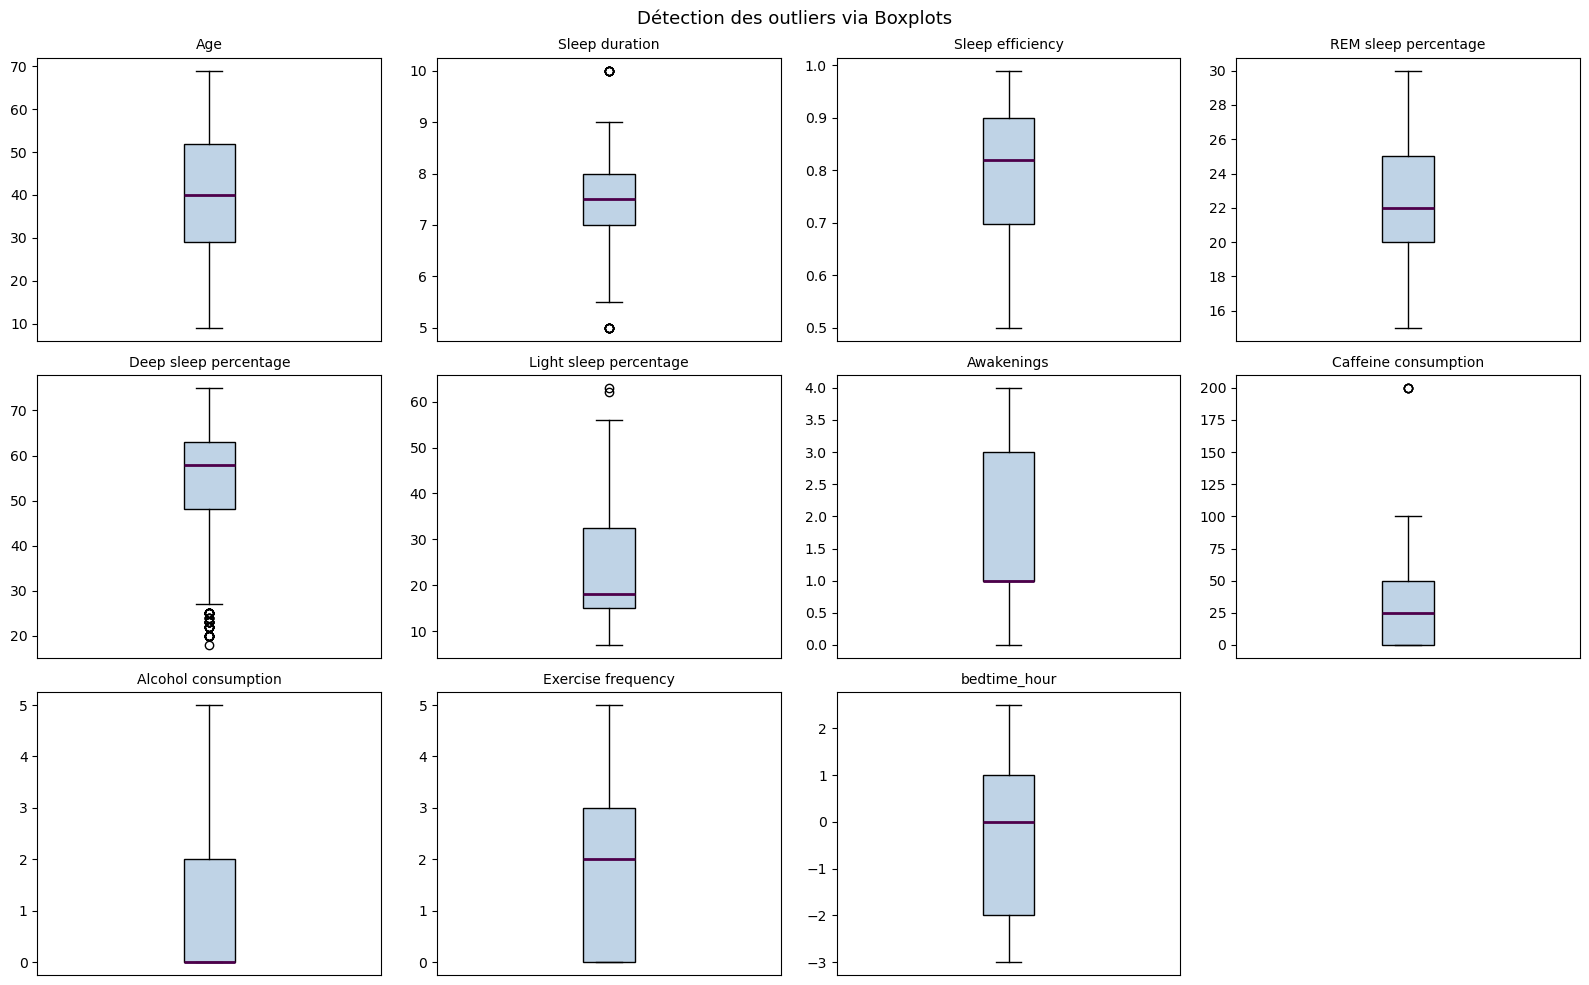

In [9]:
quant_cols = ['Age', 'Sleep duration', 'Sleep efficiency', 
              'REM sleep percentage', 'Deep sleep percentage',
              'Light sleep percentage', 'Awakenings', 
              'Caffeine consumption', 'Alcohol consumption', 
              'Exercise frequency', 'bedtime_hour']

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(quant_cols):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='#BFD3E6'),
                    medianprops=dict(color='#4D004B', linewidth=2))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xticks([])

# On cache le dernier subplot vide
axes[-1].set_visible(False)

plt.suptitle('Détection des outliers via Boxplots', fontsize=13)
plt.tight_layout()
plt.show()

Les boxplots montrent que les données sont globalement propres, avec très peu de valeurs extrêmes. La seule valeur notable est `Caffeine consumption` avec un individu à 200mg, une valeur élevée mais tout à fait réelle. Nous choisissons de la conserver telle quelle car elle reflète un comportement existant dans la population.

### 2.Analyse bidimensionnelle

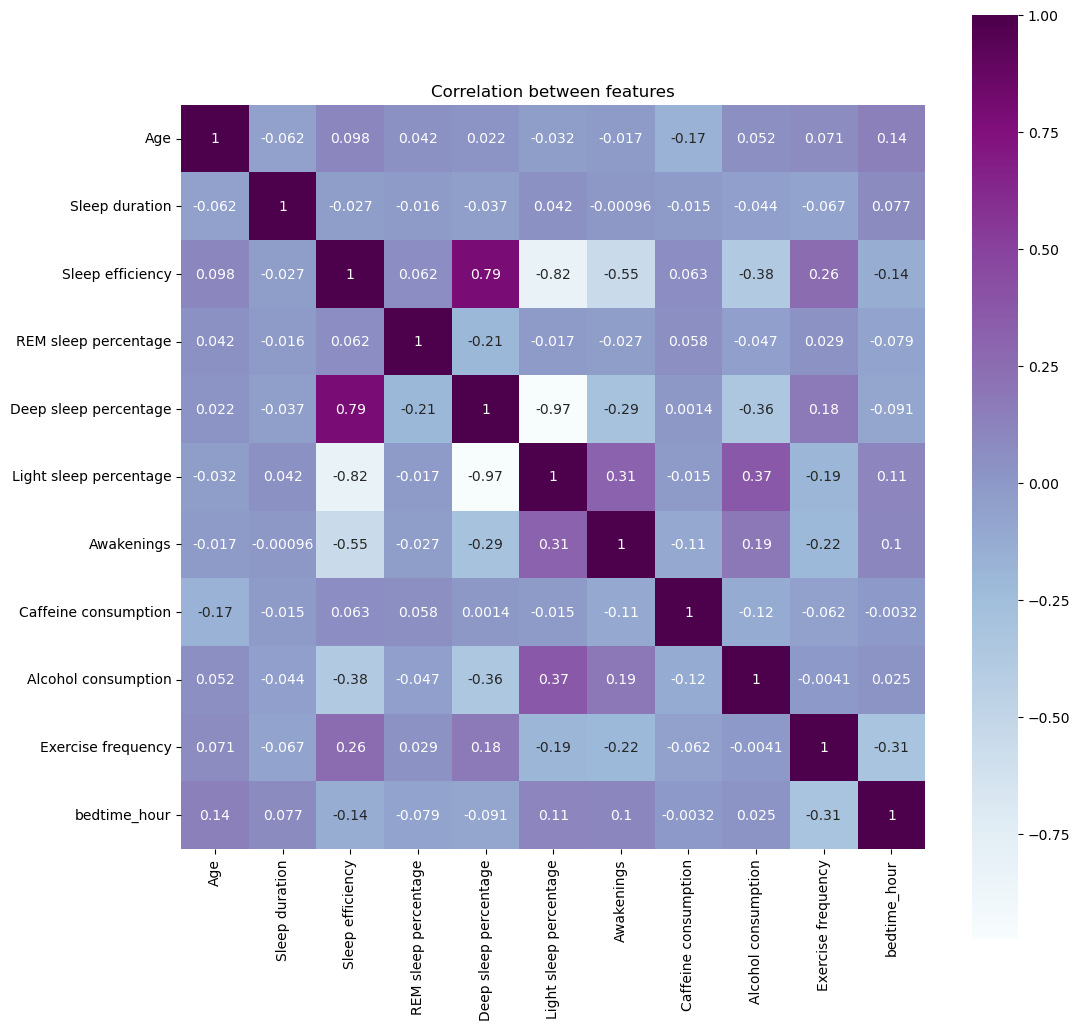

In [10]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 12))
sns.heatmap(corr, annot=True, square=True, cmap='BuPu')
plt.title('Correlation between features')
plt.show()

La matrice de corrélation met en évidence plusieurs relations :

**Corrélations fortes :**
- `Deep sleep percentage` et `Light sleep percentage` sont très fortement corrélées négativement (-0.97), ce qui est logique car ces deux variables sont complémentaires, plus on passe de temps en sommeil profond, moins on passe de temps en sommeil léger. 
- `Sleep efficiency` et `Deep sleep percentage` sont fortement corrélées positivement (0.79), un sommeil plus profond est associé à une meilleure efficacité du sommeil.
- `Sleep efficiency` et `Light sleep percentage` sont fortement corrélées négativement (-0.82), plus on passe de temps en sommeil léger, moins le sommeil est efficace.

**Corrélations modérées :**
- `Awakenings` et `Sleep efficiency` (-0.55), se réveiller souvent
la nuit dégrade la qualité du sommeil.
- `Alcohol consumption` et `Sleep efficiency` (-0.38), la consommation
d'alcool est associée à une moins bonne qualité de sommeil.
- `Exercise frequency` et `bedtime_hour` (-0.31), les personnes qui
font plus de sport ont tendance à se coucher plus tôt.

**Le reste des variables** présente des corrélations faibles, ce qui
suggère qu'elles apportent des informations indépendantes et complémentaires.

### 3. Analyse en composantes pricipales (ACP)


Nous manipulons ici des individus décrits par 11 dimensions (nos variables quantitatives), ce qui s'avère trop complexe à visualiser directement. Pour mieux appréhender les relations entre ces individus et leurs habitudes de sommeil, nous pouvons utiliser l'ACP pour les projeter dans un espace de dimension réduite, beaucoup plus facile à interpréter. 
Les variables étant exprimées dans des unités différentes, sont centrées et réduites afin qu'aucune variable ne domine les autres du fait de son échelle.

In [11]:
import prince

# On récupère les variables quantitatives
X = df[quant_cols]

# PCA avec prince
pca = prince.PCA(
    n_components=8,
    n_iter=10,
    rescale_with_mean=True,
    rescale_with_std=True,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=42
)

# Fit du modèle
pca = pca.fit(X)

# Projection des données
projected = pca.transform(X)

X_PCA= projected.iloc[:,:3] #on retient les 3 composantes principales 

print(f"Dimension initiale: {X.shape}")
print(f"Dimension après projection: {projected.shape}\n")

print(" Variance expliquée par composante :")
summary = pca.eigenvalues_summary
print(summary)

for i in range(len(summary)):
    # On récupère la valeur brute 
    percentage = summary.iloc[i, 1] 
    print(f"Composante {i+1}: {percentage} de la variance totale")

Dimension initiale: (452, 11)
Dimension après projection: (452, 8)

 Variance expliquée par composante :
          eigenvalue % of variance % of variance (cumulative)
component                                                    
0              3.267        29.70%                     29.70%
1              1.332        12.10%                     41.80%
2              1.262        11.47%                     53.27%
3              1.086         9.87%                     63.15%
4              0.990         9.00%                     72.15%
5              0.892         8.11%                     80.26%
6              0.712         6.48%                     86.73%
7              0.700         6.36%                     93.09%
Composante 1: 29.70% de la variance totale
Composante 2: 12.10% de la variance totale
Composante 3: 11.47% de la variance totale
Composante 4: 9.87% de la variance totale
Composante 5: 9.00% de la variance totale
Composante 6: 8.11% de la variance totale
Composante 7: 6.48% 

Ce résultat nous montre que l'algorithme a bien conservé nos 452 individus, mais a condensé nos variables de départ en 8 nouvelles composantes classées par ordre d'importance. Le premier axe fait le plus gros du travail en captant près de 30 % de l'information totale à lui tout seul, puis l'apport des axes suivants baisse progressivement. On remarque d'ailleurs qu'à partir de la quatrième composante, les axes restants n'apportent plus que de faibles pourcentages (moins de 10 % d'information chacun).

Bien que nous ayons les pourcentages exacts de variance expliquée, il est toujours préférable de les représenter graphiquement. Le graphique de l'éboulis nous permet de repérer visuellement la chute d'information entre les différents axes.

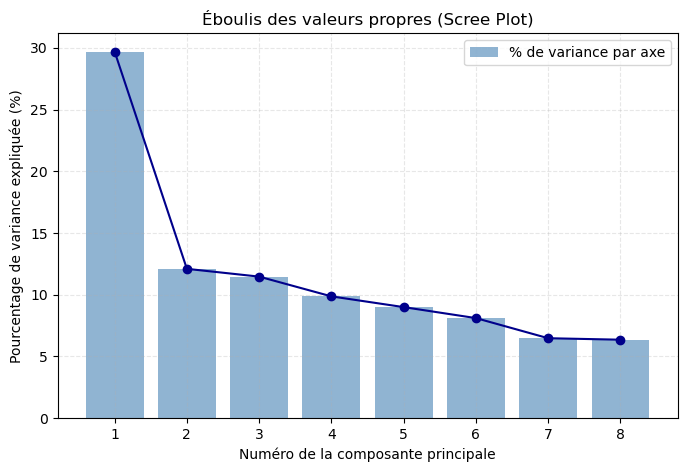

In [12]:

# On extrait les pourcentages de variance (colonne 1) et on enlève le symbole '%' pour pouvoir les tracer
# Note : summary.iloc[:, 1] contient les textes "29.70%", etc.
variances = summary.iloc[:, 1].str.replace('%', '').astype(float)

plt.figure(figsize=(8, 5))

# Création du graphique 
plt.bar(range(1, len(variances) + 1), variances, alpha=0.6, color='steelblue', label="% de variance par axe")
plt.plot(range(1, len(variances) + 1), variances, marker='o', color='darkblue')

plt.title("Éboulis des valeurs propres (Scree Plot)")
plt.xlabel("Numéro de la composante principale")
plt.ylabel("Pourcentage de variance expliquée (%)")

# Mieux visualiser les numéros entiers sur l'axe X 
plt.xticks(range(1, len(variances) + 1))
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()

plt.show()

L'observation de cet éboulis des valeurs propres confirme visuellement la chute d'information après le premier axe. Il nous faudrait conserver au moins 6 composantes pour atteindre le seuil recommandé des 80 % de variance expliquée. Cependant, nous faisons le choix de n'en retenir que 3. En effet, ces trois premiers axes capturent plus de 53 % de l'information totale, ce qui constitue un résumé solide. Surtout, ce choix est dicté par une nécessité de visualisation : se limiter à 3 dimensions nous permet de projeter et d'interpréter facilement le profil de nos individus sur des graphiques lisibles. Si nous avions gardé 6 composantes, toute représentation visuelle claire aurait été impossible.

Nous projetons mainentenant les observations sur les trois première composantes principales pour examiner si les individus présentent des regroupements naturels selon leur profil de sommeil 

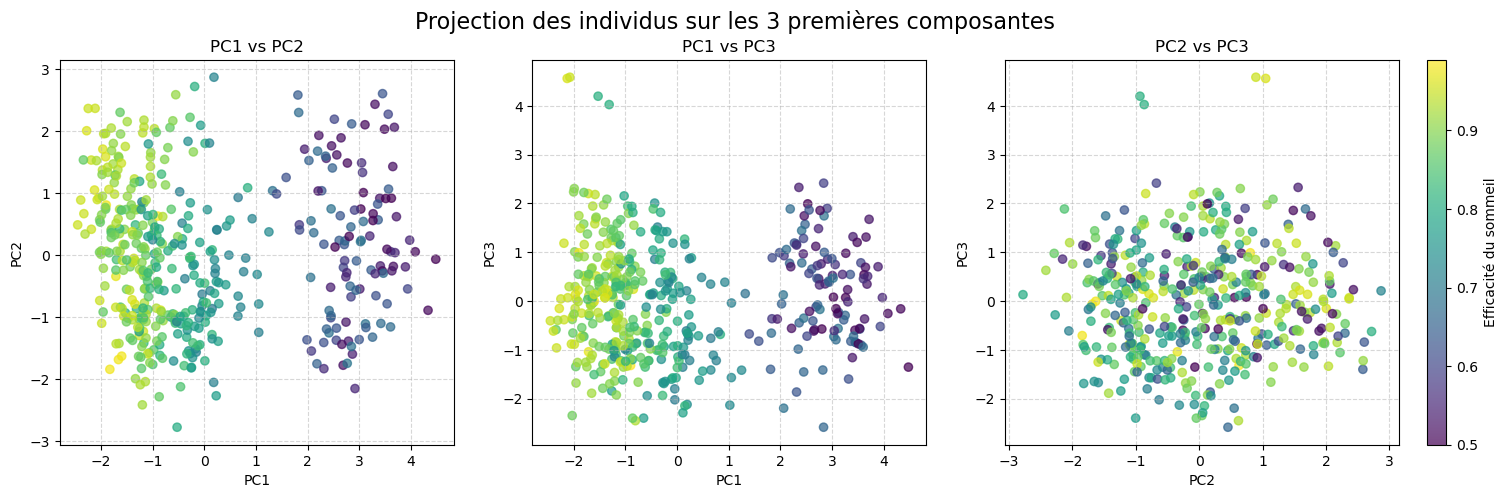

In [13]:
# Affichage des projections sur les 3 premières composantes
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Projection des individus sur les 3 premières composantes", fontsize=16)

# PC1 vs PC2
sc1 = axes[0].scatter(projected.iloc[:, 0], projected.iloc[:, 1], c=df['Sleep efficiency'], cmap='viridis', alpha=0.7)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('PC1 vs PC2')
axes[0].grid(True, linestyle='--', alpha=0.5)

# PC1 vs PC3
sc2 = axes[1].scatter(projected.iloc[:, 0], projected.iloc[:, 2], c=df['Sleep efficiency'], cmap='viridis', alpha=0.7)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC3')
axes[1].set_title('PC1 vs PC3')
axes[1].grid(True, linestyle='--', alpha=0.5)

# PC2 vs PC3
sc3 = axes[2].scatter(projected.iloc[:, 1], projected.iloc[:, 2], c=df['Sleep efficiency'], cmap='viridis', alpha=0.7)
axes[2].set_xlabel('PC2')
axes[2].set_ylabel('PC3')
axes[2].set_title('PC2 vs PC3')
axes[2].grid(True, linestyle='--', alpha=0.5)

# On ajoute une seule barre de couleur commune tout à droite
cbar = fig.colorbar(sc1, ax=axes, orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label("Efficacité du sommeil")

plt.show()

En observant les deux premiers graphiques, on constate que la séparation parfaite entre les bons et les mauvais dormeurs se fait de manière stricte le long de l'axe PC1. À l'inverse, le troisième graphique (PC2 vs PC3) affiche un nuage de points où les couleurs sont totalement mélangées. La conclusion majeure à en tirer est que notre première composante a réussi à capter la quasi-totalité des facteurs qui influencent l'efficacité du sommeil. Les composantes 2 et 3 représentent d'autres profils comportementaux de nos patients (comme peut-être des habitudes de consommation ou l'âge) qui structurent notre jeu de données mais qui n'ont pas d'impact direct ou systématique sur la qualité globale de leur sommeil.

Puisque l'axe PC1 joue un rôle principal dans la séparation des différents profils de dormeurs. Il est donc pertinent de réaliser des cercles de corrélations afin de visualiser les variables associées a cet axe. 

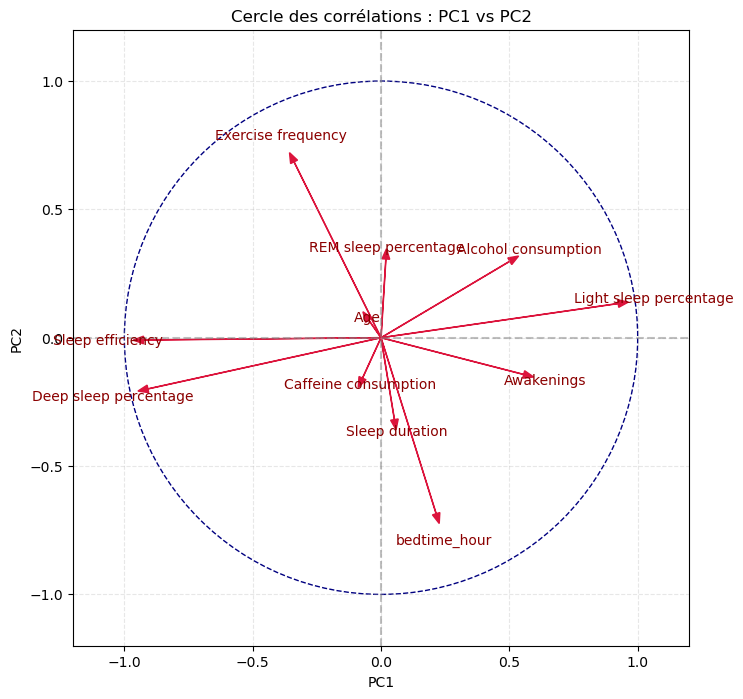

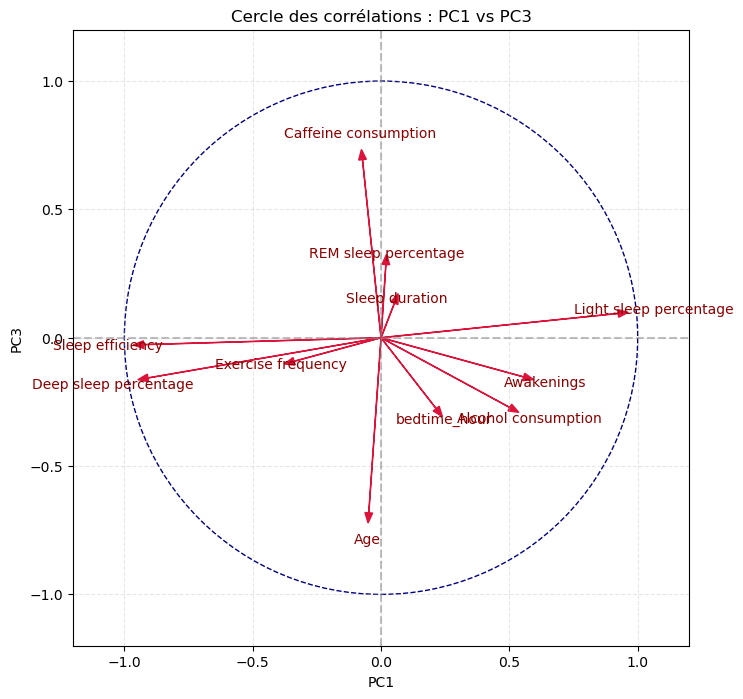

In [14]:
correlations = pca.column_correlations

def plot_correlation_circle(comp_x, comp_y):
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Dessin du cercle unité
    circle = plt.Circle((0, 0), 1, color='navy', fill=False, linestyle='--')
    ax.add_artist(circle)
    
    # Axes
    plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
    plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
    
    # Variables
    for i, var in enumerate(correlations.index):
        x = correlations.iloc[i, comp_x]
        y = correlations.iloc[i, comp_y]
        
        # Dessin de la flèche
        ax.arrow(0, 0, x, y, head_width=0.03, head_length=0.04, fc='crimson', ec='crimson')
        # Ajout du texte
        plt.text(x*1.15, y*1.15, var, color='darkred', ha='center', va='center', fontsize=10)

    plt.xlim(-1.2, 1.2)
    plt.ylim(-1.2, 1.2)
    ax.set_aspect('equal')
    plt.title(f"Cercle des corrélations : PC{comp_x+1} vs PC{comp_y+1}")
    plt.xlabel(f"PC{comp_x+1}")
    plt.ylabel(f"PC{comp_y+1}")
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()

# Affichage des deux vues principales
plot_correlation_circle(0, 1) # PC1 vs PC2
plot_correlation_circle(0, 2) # PC1 vs PC3

L’axe PC1 oppose clairement deux profils de dormeurs. D’un côté, *Awakenings*, *Alcohol consumption* et *Light sleep percentage* sont fortement corrélées et vont dans la même direction : elles traduisent un sommeil plus fragmenté et moins réparateur. À l’inverse, *Sleep efficiency* et *Deep sleep percentage* pointent dans la direction opposée et caractérisent un sommeil plus profond et efficace.  

Cela explique pourquoi, dans les projections précédentes, les « bons dormeurs » et les « mauvais dormeurs » étaient séparés presque uniquement le long de PC1.

L’axe PC2 semble refléter des différences comportementales entre les individus. Les variables *Exercise frequency* et *REM sleep percentage* s’opposent aux profils associés à des horaires de coucher plus tardifs (*bedtime_hour*). Cet axe semble donc séparer des profils plutôt sportifs de profils davantage « couche-tard ». Contrairement à PC1, il ne distingue pas clairement les bons et les mauvais dormeurs : il décrit surtout des habitudes propres aux individus, sans lien direct systématique avec l’efficacité globale du sommeil.



Le second cercle confirme le rôle central de PC1 dans la qualité du sommeil. On retrouve la même opposition entre sommeil profond et sommeil fragmenté.

L’axe PC3 met davantage en évidence des différences individuelles, notamment une opposition entre *Age* et *Caffeine consumption*, suggérant que les individus les plus jeunes consomment davantage de caféine. Ces variables participent au profil des patients mais influencent moins directement l’efficacité globale du sommeil.




Après avoir analysé les relations entre les variables quantitatives, il est intéressant d’examiner si certaines variables qualitatives présentent également une structure particulière dans l’espace factoriel.
Nous projetons donc les individus sur le premier plan de l’ACP en distinguant les catégories des variables qualitatives `Smoking status` et `Gender` .

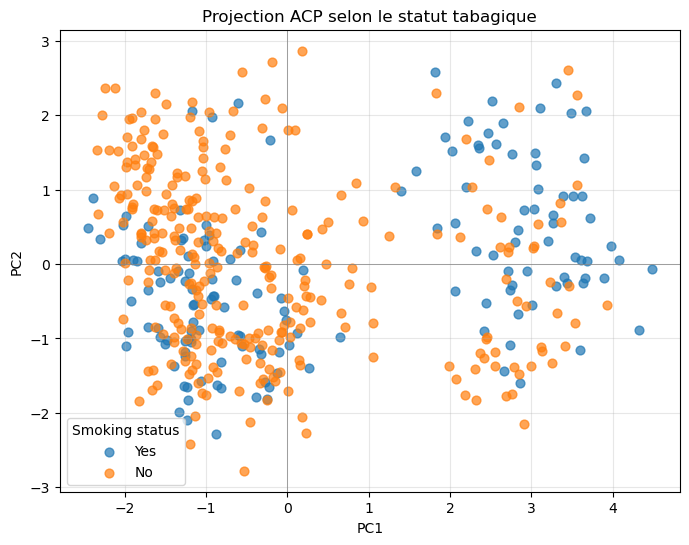

In [15]:

pca_plot = projected.iloc[:, :2].copy()

pca_plot["Smoking status"] = df["Smoking status"].values

plt.figure(figsize=(8,6))

for status in pca_plot["Smoking status"].unique():
    
    mask = pca_plot["Smoking status"] == status
    
    plt.scatter(
        pca_plot.loc[mask, 0],
        pca_plot.loc[mask, 1],
        label=status,
        alpha=0.7,
        s=40
    )

plt.axhline(0, color='grey', linewidth=0.5)
plt.axvline(0, color='grey', linewidth=0.5)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("Projection ACP selon le statut tabagique")

plt.legend(title="Smoking status")

plt.grid(True, alpha=0.3)

plt.show()

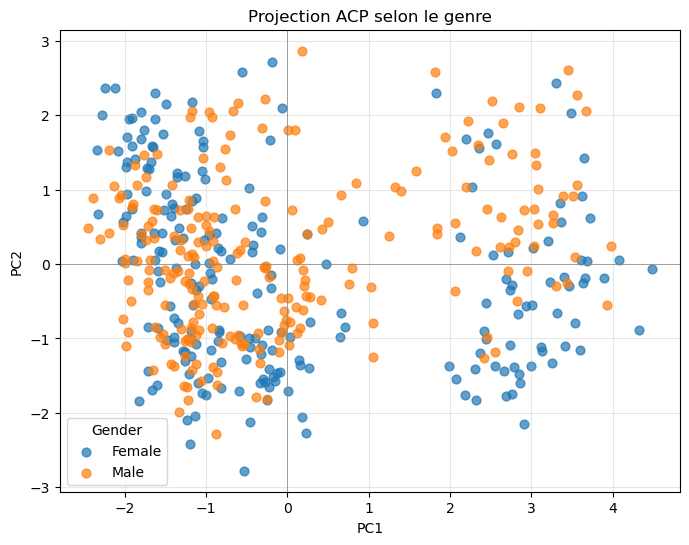

In [16]:

pca_plot = projected.iloc[:, :2].copy()

pca_plot["Gender"] = df["Gender"].values


plt.figure(figsize=(8,6))

for gender in pca_plot["Gender"].unique():
    
    mask = pca_plot["Gender"] == gender
    
    plt.scatter(
        pca_plot.loc[mask, 0],
        pca_plot.loc[mask, 1],
        label=gender,
        alpha=0.7,
        s=40
    )

plt.axhline(0, color='grey', linewidth=0.5)
plt.axvline(0, color='grey', linewidth=0.5)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("Projection ACP selon le genre")

plt.legend(title="Gender")

plt.grid(True, alpha=0.3)

plt.show()

Les projections ACP selon le genre et le statut tabagique montrent un fort mélange des catégories dans l’espace factoriel. Aucune séparation nette n’apparaît le long de l’axe PC1, pourtant associé à la qualité globale du sommeil.

Dans notre jeu de données, le genre et le statut tabagique ne semblent donc pas constituer des facteurs discriminants majeurs des profils de sommeil. 

L’ACP a mis en évidence une structuration claire des individus, principalement portée par la composante PC1, qui oppose des profils de sommeil efficaces à des profils plus fragmentés. Cette organisation suggère l’existence possible de groupes naturels de dormeurs au sein des données.  

Il devient donc pertinent de se poser la question suivante : **les individus peuvent-ils être regroupés en profils homogènes selon leurs caractéristiques de sommeil ?** Pour explorer cette hypothèse, nous allons utiliser des méthodes de clustering.

### 4.FAMD

In [39]:
sleep_clip = df[[
    'Gender',
    'Age',
    'Sleep duration',
    'Sleep efficiency',
    'REM sleep percentage',
    'Deep sleep percentage',
    #'Light sleep percentage',  ← retire cette ligne, redondante avec Deep sleep et REM sleep
    'Awakenings',
    'Caffeine consumption',
    'Alcohol consumption',
    'Smoking status',
    'Exercise frequency',
    'bedtime_hour'
]].copy()

sleep_clip["Gender"] = sleep_clip["Gender"].astype("category")

sleep_clip["Smoking status"] = sleep_clip["Smoking status"].astype("category")

In [40]:
print(sleep_clip.isnull().sum())
print("")
print(sleep_clip.dtypes)

Gender                   0
Age                      0
Sleep duration           0
Sleep efficiency         0
REM sleep percentage     0
Deep sleep percentage    0
Awakenings               0
Caffeine consumption     0
Alcohol consumption      0
Smoking status           0
Exercise frequency       0
bedtime_hour             0
dtype: int64

Gender                   category
Age                         int64
Sleep duration            float64
Sleep efficiency          float64
REM sleep percentage        int64
Deep sleep percentage       int64
Awakenings                float64
Caffeine consumption      float64
Alcohol consumption       float64
Smoking status           category
Exercise frequency        float64
bedtime_hour              float64
dtype: object


Les trois phases de sommeil vérifient la contrainte  qui introduit une dépendance linéaire exacte entre REM sleep percentage + Deep sleep percentage + Light sleep percentage. Conserver les trois variables simultanément provoquerait une colinéarité parfaite nuisible à l'analyse factorielle. Parmi les trois, Light sleep percentage est retirée car elle est quasi-redondante avec Deep sleep percentage , tandis que REM sleep percentage apporte une information indépendante visible dans le cercle des corrélations de l'ACP.

In [50]:
import prince

# FAMD model
famd = prince.FAMD(
    n_components=10,
    n_iter=10,
    copy=True,
    check_input=True,
    random_state=42,
    engine="sklearn",
    handle_unknown="error"
)

# Fit model
famd = famd.fit(sleep_clip)


In [51]:
display(famd.eigenvalues_summary)

famd.scree_plot()

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,5.676,2.17%,2.17%
1,5.598,2.14%,4.30%
2,5.411,2.07%,6.37%
3,5.108,1.95%,8.32%
4,5.035,1.92%,10.24%
5,4.895,1.87%,12.11%
6,4.806,1.83%,13.94%
7,4.597,1.75%,15.70%
8,4.288,1.64%,17.33%


alt.Chart(...)

Contrairement à l'ACP où le premier axe captait à lui seul ~30% de la variance, la FAMD distribue l'information de manière beaucoup plus uniforme entre les composantes. Cela s'explique par la nature de la méthode : en intégrant les indicatrices des variables qualitatives, la FAMD opère sur un espace de dimension plus élevée, ce qui dilue mécaniquement la variance par axe. L'absence de coude franc dans l'éboulis est donc un comportement attendu et non un signe de mauvaise qualité du modèle. En appliquant la règle de Kaiser (valeur propre > 1), les 10 premières composantes sont toutes retenues. Pour des raisons de visualisation, nous nous limiterons aux 3 premiers axes dans la suite de l'analyse.

In [35]:
def plot_famd(ax1=0, ax2=1, famd=famd, data=sleep_clip):

    dataset = famd.transform(data)

    sns.scatterplot(
        data=dataset,
        x=ax1,
        y=ax2,
        hue=data["Gender"],   # ou une autre variable catégorielle
        alpha=0.7
    )

    plt.xlabel(
        f'Component {ax1} — {famd.percentage_of_variance_[ax1]:.2f}%'
    )

    plt.ylabel(
        f'Component {ax2} — {famd.percentage_of_variance_[ax2]:.2f}%'
    )

    plt.grid(True)
    plt.show()


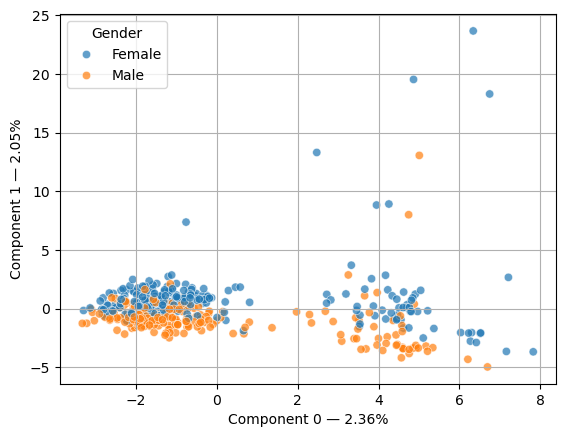

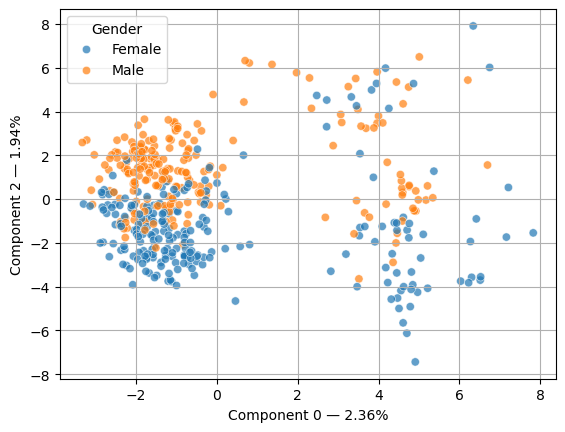

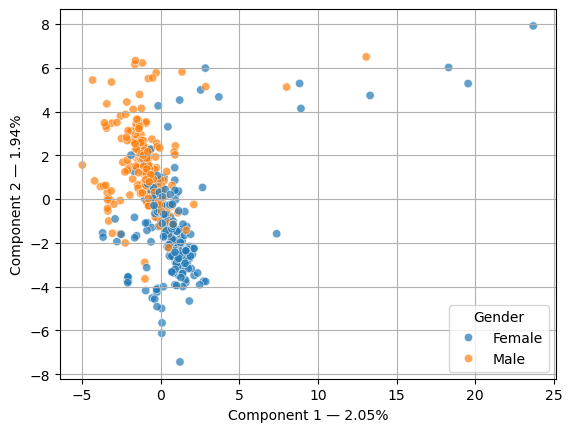

In [36]:
plot_famd(0,1)
plot_famd(0,2)
plot_famd(1,2)

La FAMD confirme la structure principale déjà identifiée en ACP : les individus se organisent d'abord selon la qualité globale de leur sommeil le long du premier axe. Cependant, en intégrant les variables qualitatives Gender et Smoking status comme variables actives, elle apporte une information complémentaire : une différenciation selon le genre émerge sur les axes suivants, ce qui n'était pas visible dans l'analyse purement quantitative. La FAMD offre donc une vision plus complète des profils de dormeurs en combinant dans un même espace factoriel les dimensions comportementales, physiologiques et démographiques.

#### Contributions des variables

In [52]:
contrib = famd.column_contributions_.style.format('{:.2%}')
display(contrib.highlight_max(color='orange').highlight_min(color='lightblue'))

component,0,1,2,3,4,5,6,7,8,9
variable,,,,,,,,,,
Sleep duration,0.50%,0.18%,0.02%,0.03%,0.28%,0.03%,0.00%,0.03%,0.02%,0.00%
Sleep efficiency,1.45%,2.74%,0.34%,0.39%,0.18%,3.45%,3.45%,0.78%,0.59%,0.23%
Awakenings,0.89%,0.94%,0.04%,0.84%,0.01%,0.18%,0.68%,0.05%,0.19%,0.02%
Caffeine consumption,0.37%,2.09%,0.07%,0.46%,0.00%,0.00%,0.02%,0.85%,0.00%,0.64%
Alcohol consumption,0.02%,1.20%,0.58%,0.06%,0.06%,0.53%,0.73%,0.82%,0.38%,0.45%
Exercise frequency,4.46%,0.03%,1.05%,0.60%,0.10%,0.13%,0.24%,0.00%,0.06%,0.26%
bedtime_hour,3.21%,0.56%,0.28%,0.20%,0.61%,0.10%,0.11%,0.12%,0.38%,0.08%
Age,7.89%,8.36%,9.98%,11.67%,12.26%,8.75%,11.38%,13.07%,14.10%,11.93%
Deep sleep percentage,13.36%,11.35%,14.20%,13.66%,14.48%,16.34%,15.89%,16.26%,13.81%,14.55%



L’analyse des contributions montre que les variables les plus importantes dans la construction des axes factoriels sont principalement liées à la qualité et à la structure du sommeil. Les variables Deep sleep percentage et REM sleep percentage présentent les contributions les plus élevées sur la majorité des composantes, ce qui indique qu’elles jouent un rôle central dans la différenciation des individus.

### Clustering K-means 

Nous commençons par la méthode des K-means, une approche de clustering largement utilisée pour identifier des groupes d’individus présentant des caractéristiques similaires. Avant de construire les clusters, il est toutefois nécessaire de déterminer le nombre de groupes le plus pertinent à partir des données.

##### Préparation et choix de K :

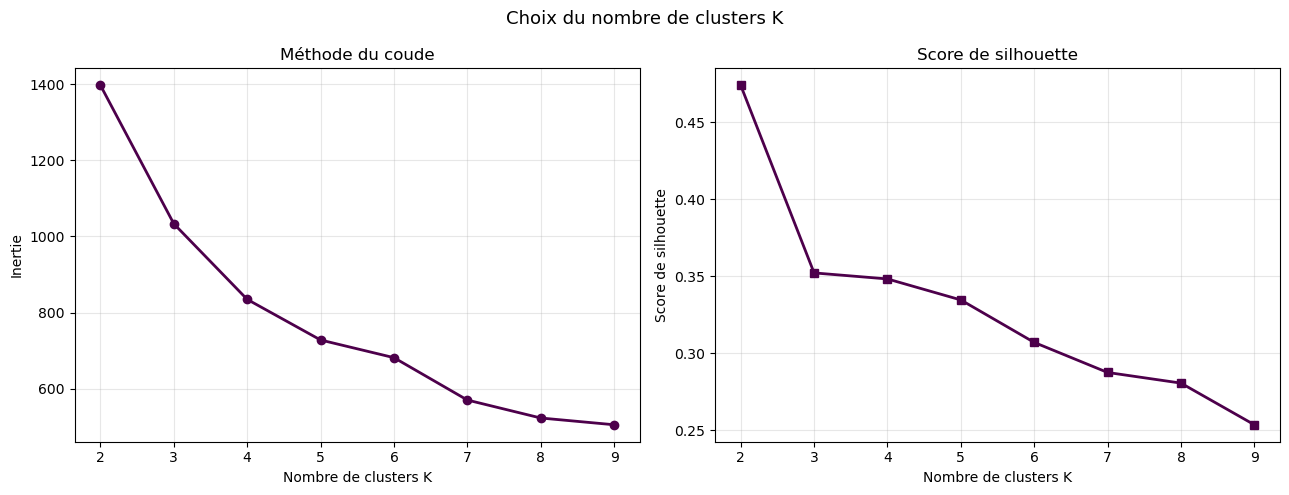

Meilleur K : 2


In [18]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples


# Choix de K
inertias, silhouettes = [], []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', 
                n_init='auto', max_iter=100, random_state=42)
    labels = km.fit_predict(X_PCA)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_PCA, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(list(k_range), inertias, 'o-', color='#4D004B', linewidth=2)
ax1.set_xlabel('Nombre de clusters K')
ax1.set_ylabel('Inertie')
ax1.set_title('Méthode du coude')
ax1.set_xticks(list(k_range))
ax1.grid(True, alpha=0.3)

ax2.plot(list(k_range), silhouettes, 's-', color='#4D004B', linewidth=2)
ax2.set_xlabel('Nombre de clusters K')
ax2.set_ylabel('Score de silhouette')
ax2.set_title('Score de silhouette')
ax2.set_xticks(list(k_range))
ax2.grid(True, alpha=0.3)

plt.suptitle('Choix du nombre de clusters K', fontsize=13)
plt.tight_layout()
plt.show()


print(f"Meilleur K : {list(k_range)[silhouettes.index(max(silhouettes))]}")

Les deux graphiques pointent vers **K = 2**, le score de silhouette est maximal et l'inertie commence à peine à décroître après ce point. On retient donc **K = 2**.

#### Application du Clustering avec le K choisi

In [19]:
K_FINAL = 2

# Application du K-means final
kmeans_final = KMeans(n_clusters=K_FINAL, init='k-means++',
                      n_init=50, max_iter=300, random_state=42)
clusters = kmeans_final.fit_predict(X_PCA)

sil = silhouette_score(X_PCA, clusters)
print(f"Score de silhouette final : {sil:.3f}")
print(f"\nTaille des clusters :")
unique, counts = np.unique(clusters, return_counts=True)
for k, n in zip(unique, counts):
    print(f"  Cluster {k+1} : {n} individus")

Score de silhouette final : 0.474

Taille des clusters :
  Cluster 1 : 116 individus
  Cluster 2 : 336 individus


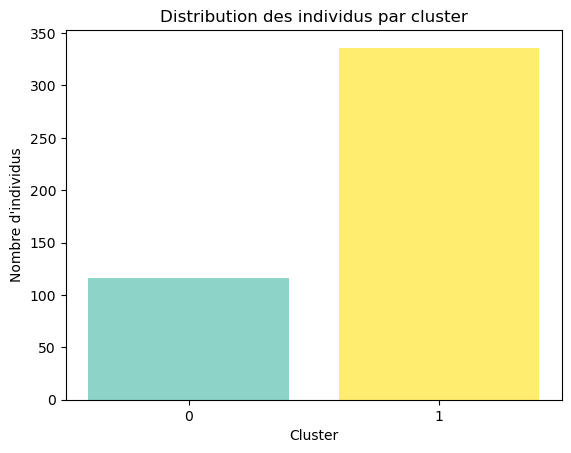

In [20]:
cmp = plt.get_cmap('Set3',K_FINAL)
unique = np.unique(clusters)
plt.bar(*np.unique(clusters,return_counts=True), color=cmp.colors)
plt.ylabel("Nombre d'individus")
plt.xlabel("Cluster")
plt.title("Distribution des individus par cluster")
plt.xticks(list(unique))
plt.show()

Le K-means identifie deux clusters avec **116 individus** dans le premier et **336 dans le second**. 
Le score de silhouette de **0.474** indique une séparation modérée les clusters existent mais ne sont pas parfaitement distincts.

#### Visualisation sur le plan de l'ACP

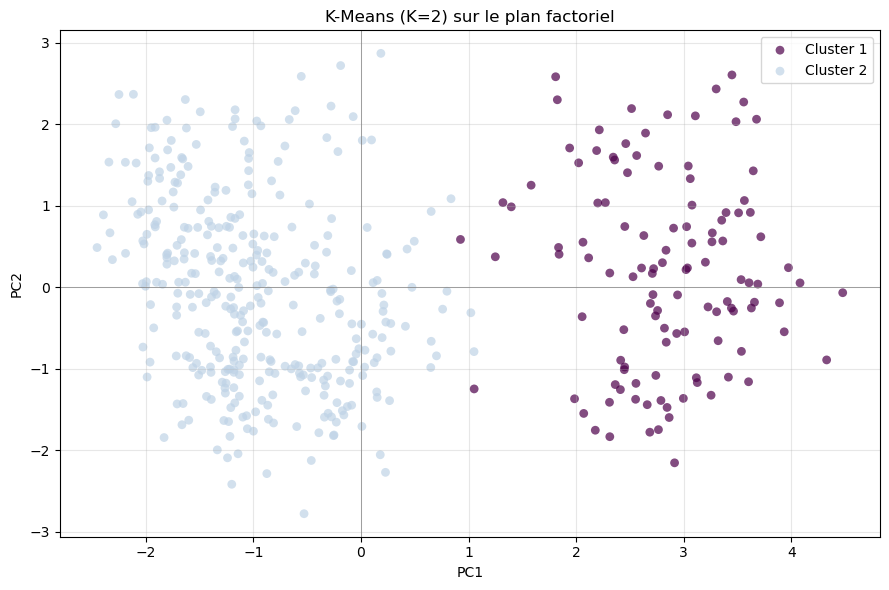

In [21]:
# Visualisation des clusters K-Means sur le plan factoriel

palette = ['#4D004B', '#BFD3E6']

fig, ax = plt.subplots(figsize=(9, 6))

for k in range(K_FINAL):
    
    mask = clusters == k
    
    ax.scatter(
        X_PCA.iloc[mask, 0],   # PC1
        X_PCA.iloc[mask, 1],   # PC2
        color=palette[k],
        label=f'Cluster {k+1}',
        alpha=0.7,
        s=40,
        edgecolors='none'
    )

ax.axhline(0, color='grey', linewidth=0.5)
ax.axvline(0, color='grey', linewidth=0.5)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')

ax.set_title(f'K-Means (K={K_FINAL}) sur le plan factoriel')

ax.legend()

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

La séparation entre les deux clusters est très nette le long de l’axe PC1.  
Le **Cluster 1** (violet, 116 individus) est principalement situé à droite du plan factoriel correspondant aux individus avec une **faible efficacité de sommeil**, tandis que le **Cluster 2** (gris clair, 336 individus) occupe la partie gauche  regroupant les **bons dormeurs**.

Ce résultat est cohérent avec l'interprétation de PC1 comme axe de qualité du sommeil établie précédemment.


In [22]:
# Ajouter les clusters au dataframe
df_ref = df.dropna(subset=quant_cols).reset_index(drop=True)
df_ref['cluster'] = clusters + 1  # pour avoir Cluster 1 et 2

# Moyennes par cluster
profile = df_ref.groupby('cluster')[quant_cols].mean().round(2)
display(profile.T.style.background_gradient(cmap='BuPu'))

cluster,1,2
Age,38.570000,40.880000
Sleep duration,7.510000,7.450000
Sleep efficiency,0.590000,0.860000
REM sleep percentage,22.350000,22.710000
Deep sleep percentage,28.220000,61.320000
Light sleep percentage,49.420000,15.980000
Awakenings,2.380000,1.350000
Caffeine consumption,22.410000,24.180000
Alcohol consumption,2.210000,0.770000
Exercise frequency,1.280000,1.970000


Le tableau des moyennes par cluster révèle deux profils bien distincts :

**Cluster 1 : Mauvais dormeurs (116 individus) :**
- `Sleep efficiency`: très faible (0.59 vs 0.86)
- Beaucoup de sommeil léger (50% vs 16%) et peu de sommeil profond (27% vs 61%)
- Plus de réveils nocturnes (2.35 vs 1.37)
- Plus de consommation d'alcool (2.14 vs 0.80)
- Moins d'exercice (1.29 vs 1.96)

**Cluster 2 : Bons dormeurs (336 individus) :**
- `Sleep efficiency` élevée (0.85)
- Sommeil majoritairement profond (61%)
- Moins de réveils, moins d'alcool, plus d'exercice

Les variables `Age`, `Sleep duration`, `REM sleep percentage` et 
`Caffeine consumption` sont similaires entre les deux groupes, 
elles ne semblent pas être des facteurs discriminants majeurs.

Afin de vérifier si le choix de deux clusters est réellement le plus pertinent, nous comparons également les diagrammes de silhouette obtenus pour plusieurs valeurs de K.

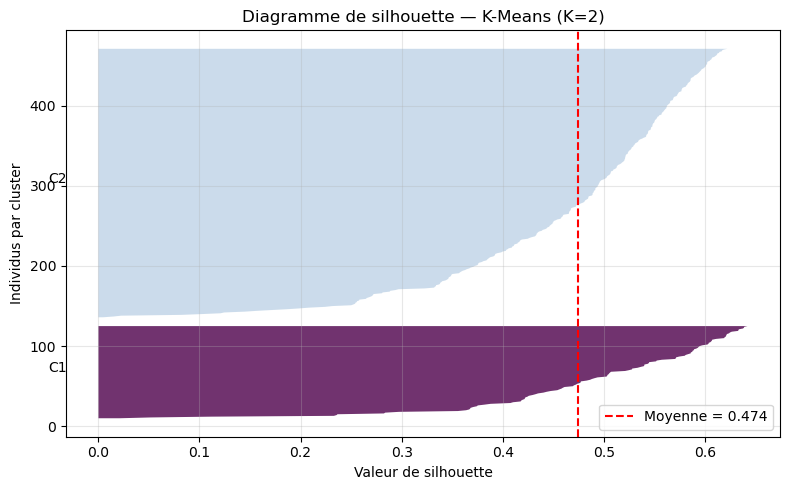

In [23]:
sil_vals = silhouette_samples(X_PCA, clusters)

fig, ax = plt.subplots(figsize=(8, 5))
palette = ['#4D004B', '#BFD3E6']
y_lower = 10

for k in range( K_FINAL):
    cluster_sil = np.sort(sil_vals[clusters == k])
    y_upper = y_lower + len(cluster_sil)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                     facecolor=palette[k], alpha=0.8)
    ax.text(-0.05, y_lower + len(cluster_sil)/2, 
            f'C{k+1}', fontsize=10)
    y_lower = y_upper + 10

ax.axvline(x=sil, color='red', linestyle='--', 
           label=f'Moyenne = {sil:.3f}')
ax.set_xlabel('Valeur de silhouette')
ax.set_ylabel('Individus par cluster')
ax.set_title(f'Diagramme de silhouette — K-Means (K={K_FINAL})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

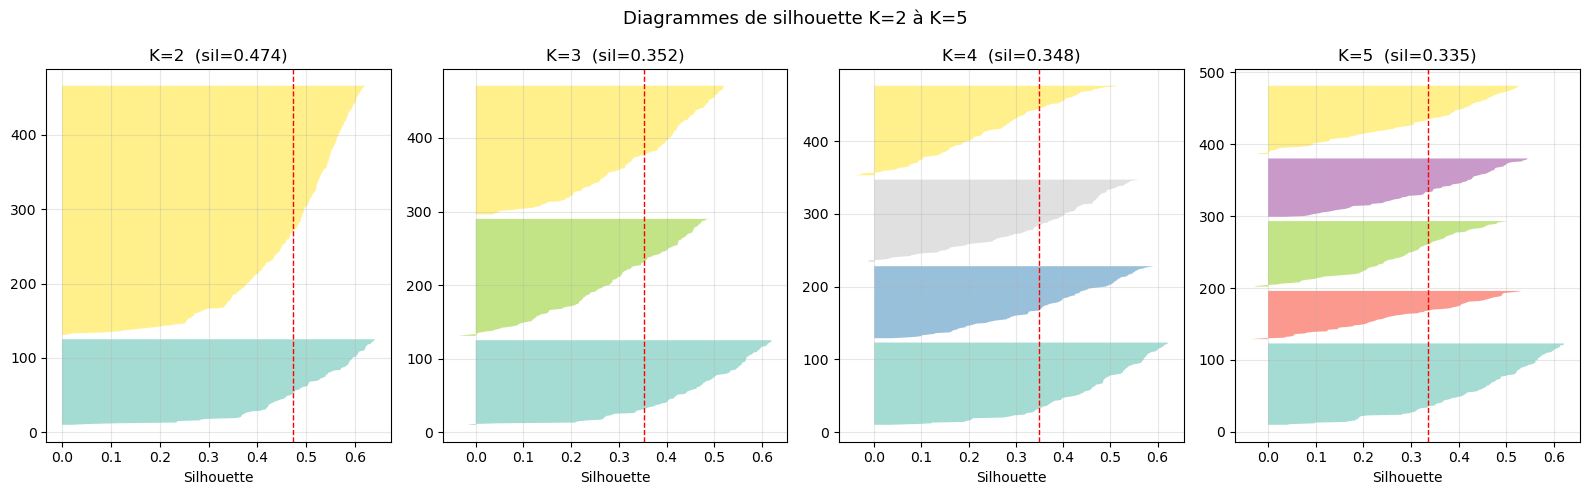

In [24]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for idx, k in enumerate(range(2, 6)):
    km = KMeans(n_clusters=k, init='k-means++',
                n_init='auto', max_iter=100, random_state=42)
    labels = km.fit_predict(X_PCA)
    sil_vals_k = silhouette_samples(X_PCA, labels)
    avg_sil = silhouette_score(X_PCA, labels)
    
    colors = plt.cm.Set3(np.linspace(0, 1, k))
    y_lower = 10
    
    for i in range(k):
        cluster_sil = np.sort(sil_vals_k[labels == i])
        y_upper = y_lower + len(cluster_sil)
        axes[idx].fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                                facecolor=colors[i], alpha=0.8)
        y_lower = y_upper + 5
    
    axes[idx].axvline(x=avg_sil, color='red', linestyle='--', linewidth=1)
    axes[idx].set_title(f'K={k}  (sil={avg_sil:.3f})')
    axes[idx].set_xlabel('Silhouette')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Diagrammes de silhouette K=2 à K=5', fontsize=13)
plt.tight_layout()
plt.show()

Les diagrammes de silhouette pour K=2 à K=5 confirment que **K=2**
est la meilleure partition :

- **K=2** présente le score de silhouette le plus élevé (0.477), ce qui indique une bonne séparation entre les deux groupes. Le grand cluster (jaune, 336 individus) apparaît relativement cohérent : la majorité de ses individus possède des valeurs de silhouette positives, signe d’une bonne séparation globale du groupe.
Le second cluster (turquoise, 116 individus) est légèrement moins homogène, avec certains individus ayant des valeurs proches de 0. Cela suggère la présence de profils intermédiaires situés à la frontière entre les deux groupes, ce qui est cohérent avec la nature continue
des données de sommeil.

- **K=3** présente un score inférieur (0.385) et une partition moins stable et les clusters présentent quelques scores négatifs.

- **K=3** présente un score plus faible (0.385) ainsi qu’une structure moins stable. Certains individus possèdent des valeurs négatives, signe d’une séparation moins nette entre les clusters.

- **K=4 et K=5** présentent des scores encore plus bas (0.288 et 0.199),
avec plusieurs clusters dont les individus ont des valeurs proches de zéro
ou négatives, ces partitions ne sont pas pertinentes.

Nous retenons donc **K=2** pour la suite de l'analyse.

Les résultats obtenus avec K-means mettent donc en évidence deux grands profils de dormeurs relativement bien séparés. La structure observée semble principalement organisée autour de l’axe de qualité du sommeil identifié précédemment par l’ACP.


## Classification Ascendante et Hierarchique 

L'algorithme des K-Means a fourni des résultats satisfaisants. Nous allons essayer de le comparer à d'autres techniques de classification abordées en cours. L'algorithme DBSCAN étant très chronophage et ses résultats peu convaincants, il a été abandonné.

Dans cette section, nous nous intéressons à la Classification Ascendante Hiérarchique (CAH). Bien que la méthode CAH soit beaucoup plus gourmande en temps de calcul que le K-Means, notre jeu de données est de taille modérée, ce qui nous permet de travailler sur l'ensemble des patients sans avoir besoin de sous-échantillonner.

Afin de déterminer le nombre optimal de clusters, nous avons d'abord calculé le score de silhouette pour différentes valeurs de K. Nous utiliserons la méthode d'agrégation de Ward (Ward linkage).






C:\Users\Cashex\AppData\Local\Temp\ipykernel_51448\829858282.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


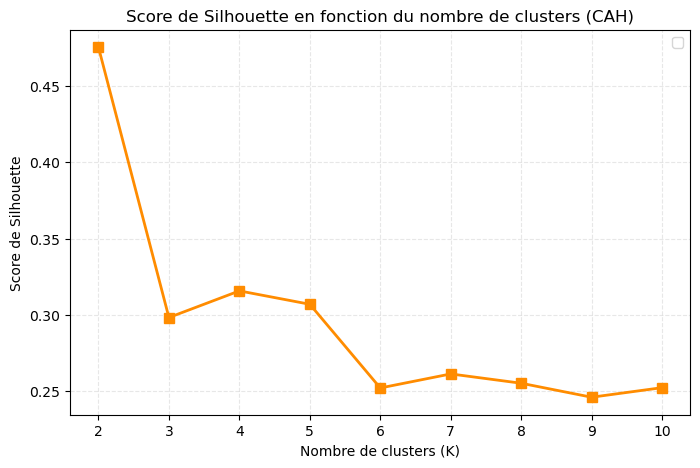

In [25]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import  AgglomerativeClustering
import numpy as np

# On va tester les K de 2 à 10
range_k = range(2, 11)
silhouette_scores = []

for k in range_k:
    # On crée le modèle pour chaque K
    cah_test = AgglomerativeClustering(n_clusters=k, linkage='ward')
    # On prédit les clusters
    clusters_test = cah_test.fit_predict(X_PCA)
    # On calcule et on sauvegarde le score
    score = silhouette_score(X_PCA, clusters_test)
    silhouette_scores.append(score)

# Tracé du graphique
plt.figure(figsize=(8, 5))
plt.plot(range_k, silhouette_scores, marker='s', color='darkorange', linewidth=2, markersize=7)
plt.title("Score de Silhouette en fonction du nombre de clusters (CAH)")
plt.xlabel("Nombre de clusters (K)")
plt.ylabel("Score de Silhouette")
plt.xticks(range_k)
plt.grid(True, linestyle='--', alpha=0.3)

plt.legend()

plt.show()

Le graphique indique un pic absolu pour K=2. Cela suggère qu'à l'échelle globale, la population de notre jeu de données se divise en deux grands blocs opposés.

Pour vérifier cette séparation,nous nous appuyons ensuite sur la méthode du coude.

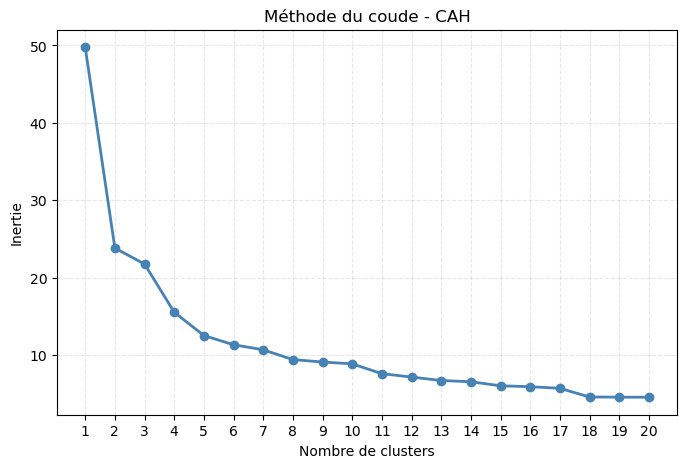

In [26]:
from sklearn.cluster import  AgglomerativeClustering

cah_model = AgglomerativeClustering(linkage="ward", compute_distances=True)
cah_model.fit(X_PCA)

n_sizes = 20
x = np.arange(n_sizes, 0, -1)
y = cah_model.distances_[-n_sizes:]

#Tracé du graphique du coude
plt.figure(figsize=(8, 5))
plt.plot(x, y, marker="o", color="steelblue", linewidth=2, markersize=6)
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertie")
plt.title("Méthode du coude - CAH")
plt.xticks(x)
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

Le graphique révèle une unique rupture majeure : un saut d'inertie gigantesque pour passer de 1 à 2 clusters. Ce coude très prononcé confirme que la séparation la plus naturelle de notre jeu de données est une division en K=2 classes. Pour visualiser cette séparation, nous générons ensuite le dendrogramme.

NameError: name 'data_for_clustering' is not defined

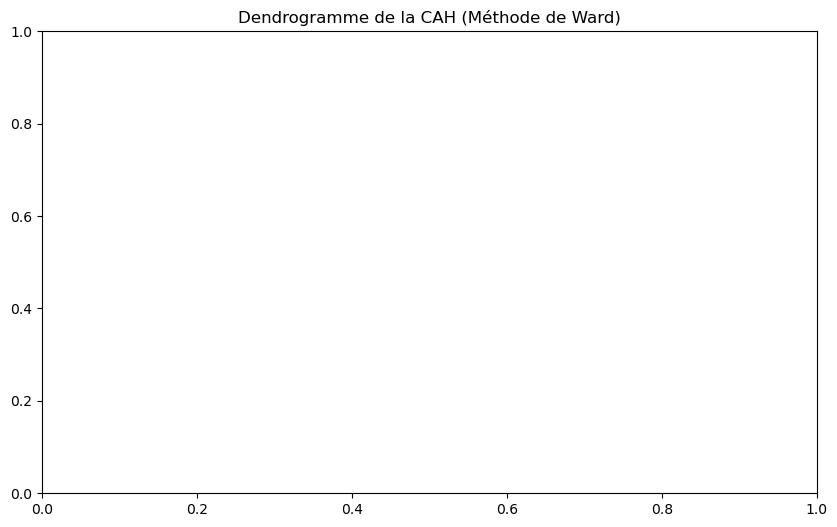

In [27]:
import scipy.cluster.hierarchy as sch

plt.figure(figsize=(10, 6))
plt.title("Dendrogramme de la CAH (Méthode de Ward)")

# Calcul des liens hiérarchiques avec SciPy
Z = sch.linkage(data_for_clustering, method='ward')

# Tracé du dendrogramme
dendrogram = sch.dendrogram(
    Z,
    truncate_mode='lastp', # On regroupe le bas de l'arbre
    p=30,                  # On n'affiche que les 30 dernières branches/groupes
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True,
    color_threshold=0  # Met tout en bleu par défaut pour l'instant
)

plt.xlabel("Nombre de patients dans la branche")
plt.ylabel("Inertie")
plt.show()

Le dendrogramme nous permet de visualiser de manière concrète la hiérarchie des regroupements effectués par l'algorithme. Sur l'axe vertical, nous lisons la distance requise pour chaque fusion.

L'élément le plus marquant de ce graphique est le très grand saut d'inertie situé tout au sommet de l'arbre. En effet, on observe que la toute dernière étape, celle qui relie les deux immenses branches pour former un groupe unique, s'effectue à une distance supérieure à 50. En comparaison, les fusions de niveau inférieur plafonnent autour d'une distance de 23.Cette étape représente de loin le saut le plus important de toute la hiérarchie. Il démontre que la séparation la plus forte et la plus naturelle au sein de notre jeu de données se situe à cet endroit précis. Une ligne de coupe horizontale tracée dans ce grand intervalle traversera exactement deux branches. Ce graphique vient donc valider visuellement, et de manière incontestable, notre choix de retenir K=2 clusters.



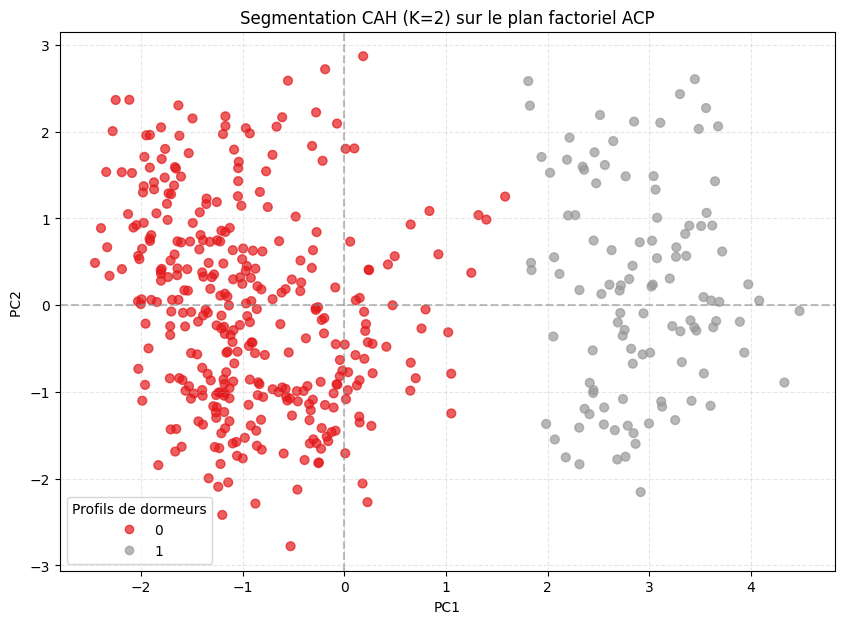

In [ ]:
K = 2
cah = AgglomerativeClustering(n_clusters=K, linkage='ward')
clusters_cah = cah.fit_predict(X_PCA)

fig, ax = plt.subplots(figsize=(10, 7))

# Scatter plot sur les deux premières composantes
scatter = ax.scatter(X_PCA.iloc[:, 0], X_PCA.iloc[:, 1], c=clusters_cah, cmap='Set1', s=40, alpha=0.7)

ax.set_title(f"Segmentation CAH (K={K}) sur le plan factoriel ACP")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2 ")
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)

# Ajout de la légende
plt.legend(*scatter.legend_elements(), title="Profils de dormeurs")
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

La projection de nos deux clusters issus de la CAH sur le premier plan factoriel de l'ACP (PC1 vs PC2) nous permet de comprendre visuellement la nature de cette segmentation binaire.

Une séparation parfaite selon la Qualité du Sommeil (PC1) : L'observation la plus marquante est la frontière de décision entre le Groupe 0 (en rouge) et le Groupe 1 (en gris). Cette séparation est quasi exclusivement verticale. Elle s'opère le long de l'axe PC1, qui concentre la variance liée à la 'Qualité du sommeil'. L'algorithme a donc naturellement scindé notre population en deux catégories opposées sur ce critère fondamental.

L'indépendance vis-à-vis du Mode de vie (PC2) : À l'inverse, on remarque que l'axe vertical (PC2), représentant le Mode de vie, ne joue aucun rôle dans cette macro-segmentation. Au sein du Groupe 0 comme du Groupe 1, les individus sont dispersés de haut en bas de l'axe PC2. Cela signifie qu'il existe des modes de vie très variés (sportifs, sédentaires, etc.) aussi bien chez les 'bons' que chez les 'mauvais' dormeurs.

En conclusion, cette visualisation confirme que le choix de K=2 isole la caractéristique la plus discriminante de notre jeu de données: la qualité du sommeil globale, reléguant les comportements annexes au second plan pour cette échelle d'analyse.

La CAH confirme donc la structure déjà observée avec l’ACP et le K-means : les données semblent principalement organisées autour de deux grands profils de sommeil opposés selon la qualité globale du sommeil (PC1).

Cependant, comme le K-means, la CAH repose sur une séparation stricte des individus entre les groupes. Or, dans des données comportementales comme celles du sommeil, certains profils peuvent être plus nuancés ou intermédiaires.

Il devient alors pertinent d’utiliser une approche probabiliste comme les Gaussian Mixture Models (GMM), qui permettent de modéliser des frontières plus souples entre les groupes.

# Gaussian Mixture Models (GMM)

#### Choix du nombre de composantes avec le critère BIC

On utilise le critère d'information bayésien (BIC) afin de déterminer le nombre optimal de composantes du modèle GMM.

Le BIC permet de trouver un compromis entre :
- la qualité d'ajustement du modèle (vraisemblance)
- la complexité du modèle (nombre de paramètres)

Le nombre optimal de clusters correspond au minimum du BIC.

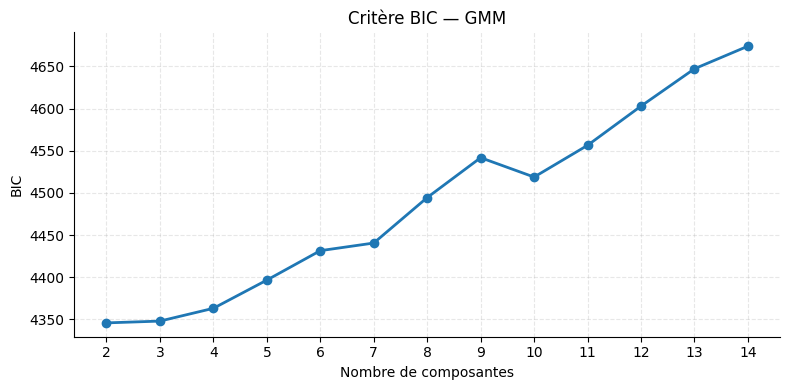

In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

k_max = 15

bic = np.array([
    GaussianMixture(n_components=k, init_params="kmeans", n_init=3, random_state=0)
    .fit(X_PCA).bic(X_PCA)
    for k in range(2, k_max)
])


fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(range(2, k_max), bic, marker="o",
        linewidth=2, markersize=6)
ax.set_xlabel("Nombre de composantes")
ax.set_ylabel("BIC")
ax.set_title("Critère BIC — GMM")
ax.set_xticks(range(2, k_max))
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()



Le critère BIC atteint son minimum pour K = 2.

Cela signifie que le modèle avec 2 clusters offre le meilleur compromis.

Au-delà de K = 2, le BIC augmente, ce qui indique que l’ajout de composantes supplémentaires entraîne un sur-ajustement, pénalisé par le critère.

Ainsi, on retient K = 2 comme nombre optimal de clusters pour le modèle GMM.

Afin de confirmer ce résultat, nous évaluons également la qualité des partitions obtenues à l’aide du score de silhouette, qui mesure à quel point les individus sont bien regroupés au sein de leur cluster et séparés des autres groupes.

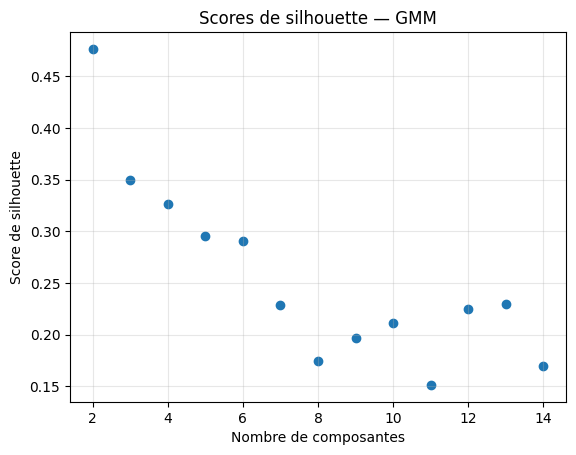

In [ ]:
k_max = 15

silhouette = []

for k in range(2, k_max):
    
    gmm = GaussianMixture(
        n_components=k,
        init_params='kmeans',
        n_init=3,
        random_state=42
    )
    
    clusters_gmm = gmm.fit_predict(X_PCA)
    
    silhouette.append(
        silhouette_score(
            projected.iloc[:, :3],
            clusters_gmm,
            metric='euclidean'
        )
    )

silhouette = np.array(silhouette)

plt.scatter(range(2, k_max), silhouette)
plt.xlabel("Nombre de composantes")
plt.ylabel("Score de silhouette")
plt.title("Scores de silhouette — GMM")
plt.grid(True, alpha=0.3)

plt.show()

Le score de silhouette atteint lui aussi sa valeur maximale pour K = 2. Cette observation confirme que la séparation en deux groupes est la plus cohérente dans l’espace des trois premières composantes principales.  

Les partitions obtenues pour des valeurs plus élevées de K présentent des scores plus faibles, ce qui suggère des clusters moins bien séparés et moins homogènes.

#### Application du modèle GMM

On applique le modèle de mélange gaussien avec le nombre de composantes sélectionné à partir du BIC.

Contrairement à K-means, le GMM permet une approche probabiliste du clustering, ce qui permet de mieux capturer des structures de données complexes.

#### Visualisation des clusters dans le plan factoriel

On représente les individus dans le plan factoriel issu de l’ACP, en les coloriant selon leur cluster GMM.

Cela permet de visualiser la structure des groupes identifiés.

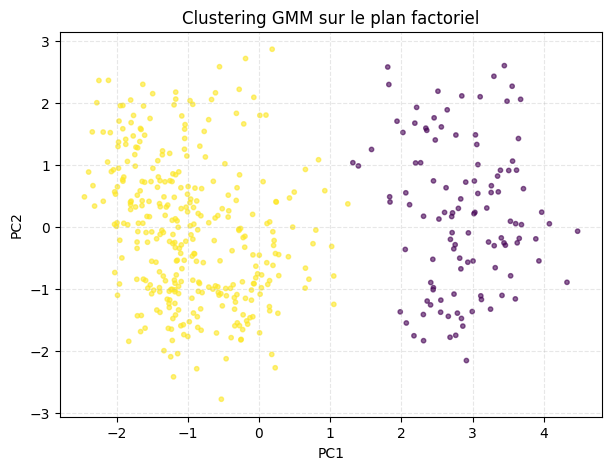

In [ ]:
from sklearn.mixture import GaussianMixture

# On utilise les 3 premières composantes de l'ACP
X_gmm = X_PCA

K = 2 # choisi à partir du BIC

gmm = GaussianMixture(
    n_components=K,
    n_init=3,
    random_state=42
)

clusters_gmm = gmm.fit_predict(X_gmm)

# Visualisation sur le plan factoriel PC1-PC2 

plt.figure(figsize=(7,5))

plt.scatter(
    projected.iloc[:, 0],
    projected.iloc[:, 1],
    c=clusters_gmm,
    s=10,
    alpha=0.6
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clustering GMM sur le plan factoriel")

plt.grid(True, linestyle="--", alpha=0.3)
plt.show()


Le modèle GMM avec K = 2 met en évidence deux grands profils de dormeurs clairement séparés dans l’espace des composantes principales.

Sur le plan factoriel, la séparation entre les deux groupes se fait principalement le long de l’axe PC1, ce qui confirme les observations réalisées précédemment avec l’ACP et le clustering K-means et CAH.

Cette représentation confirme ainsi l’existence de deux profils de sommeil bien distincts au sein des données.

Le modèle GMM conduit donc ici à une séparation très proche de celles obtenues précédemment.

Les méthodes de clustering étudiées jusqu’à présent ont permis de mettre en évidence une structure relativement claire des données, principalement portée par l’axe de qualité du sommeil. Cependant, ces approches reposent toutes sur la représentation des individus dans un espace vectoriel (variables initiales ou coordonnées ACP).

Il devient donc pertinent d’explorer une autre manière de représenter les données, cette fois sous forme de graphe de similarité entre patients. Une question naturelle est alors de savoir si la structure observée précédemment reste visible lorsque les individus sont reliés selon leurs proximités locales plutôt que simplement positionnés dans un espace géométrique.

Nous allons ainsi étudier des méthodes basées sur les graphes, notamment le Spectral Clustering et les Stochastic Block Models (SBM).

### 4. Approche Graphe : Construction du graphe

Plusieurs méthodes permettent de construire un graphe à partir de données 
tabulaires, notamment le ε-Neighborhood Graph, le k-NN Graph ou encore 
le Fully Connected Graph. Nous avons opté pour le **k-NN Graph** : 
deux individus sont reliés si l'un figure parmi les k plus proches voisins 
de l'autre, au sens de la distance euclidienne calculée sur nos variables 
quantitatives standardisées.

In [ ]:
from sklearn.neighbors import kneighbors_graph
import networkx as nx

# On s'assure que X_scaled est bien défini
X_scaled = StandardScaler().fit_transform(df[quant_cols].dropna())
# Construction du graphe k-NN avec k=7
K_GRAPH = 7
A = kneighbors_graph(X_scaled, n_neighbors=K_GRAPH, 
                     mode='connectivity', include_self=False)

# Symétrie
A = (A + A.T)
A[A > 1] = 1

# Conversion en graphe NetworkX
G = nx.from_scipy_sparse_array(A)

print(f"Nombre de noeuds : {G.number_of_nodes()}")
print(f"Nombre d'arêtes  : {G.number_of_edges()}")
print(f"Graphe connexe   : {nx.is_connected(G)}")

Nombre de noeuds : 452
Nombre d'arêtes  : 2096
Graphe connexe   : True


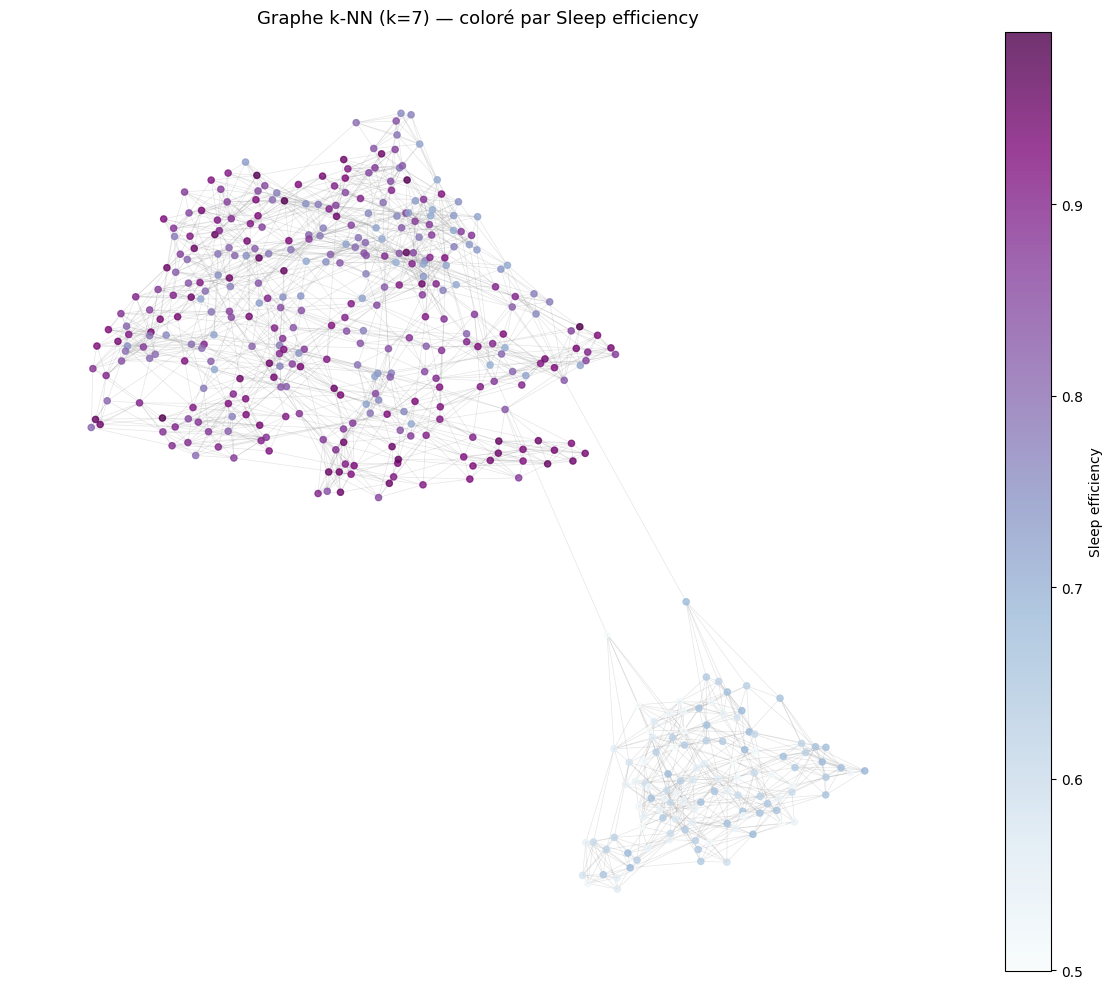

In [ ]:
# Visualisation du graphe
plt.figure(figsize=(12, 10))

# Layout — spring layout pour des données non géographiques
pos = nx.spring_layout(G, seed=42)

# Colorier les noeuds par Sleep efficiency
sleep_eff = df[quant_cols].dropna().reset_index(drop=True)
colors = df['Sleep efficiency'].dropna().reset_index(drop=True)

nodes = nx.draw_networkx_nodes(G, pos, node_size=20,
                                node_color=colors,
                                cmap='BuPu', alpha=0.8)

nx.draw_networkx_edges(G, pos, alpha=0.2, width=0.5, edge_color='gray')

plt.colorbar(nodes, label='Sleep efficiency')
plt.title(f'Graphe k-NN (k={K_GRAPH}) — coloré par Sleep efficiency', fontsize=13)
plt.axis('off')
plt.tight_layout()
plt.show()

Le graphe k-NN (k=7) révèle une structure très claire en **deux groupes distincts** :

- Le **grand groupe** en haut (violet foncé) regroupe les individus avec une Sleep efficiency élevée (> 0.8), ce sont les bons dormeurs
- Le **petit groupe** en bas à droite (bleu clair) regroupe les individus avec une Sleep efficiency faible (< 0.7), ce sont les mauvais dormeurs

Nous avons testé plusieurs valeurs de k (5, 6, 7) et retenu **k=7** car c'est la plus petite valeur pour laquelle le graphe est connexe.

Cette séparation visuelle confirme ce qu'on avait déjà observé avec le K-means, les deux clusters sont naturellement présents dans les données et se distinguent clairement par la qualité du sommeil.

### 4.2 Spectral Clustering

Le Spectral Clustering exploite le spectre du Laplacien du graphe 
pour identifier des communautés. Contrairement au K-means qui suppose 
des clusters sphériques, il peut capturer des structures plus complexes.

Nous appliquons ici le **Laplacien normalisé** (Lrw) qui est 
généralement recommandé lorsque les degrés des noeuds sont hétérogènes.

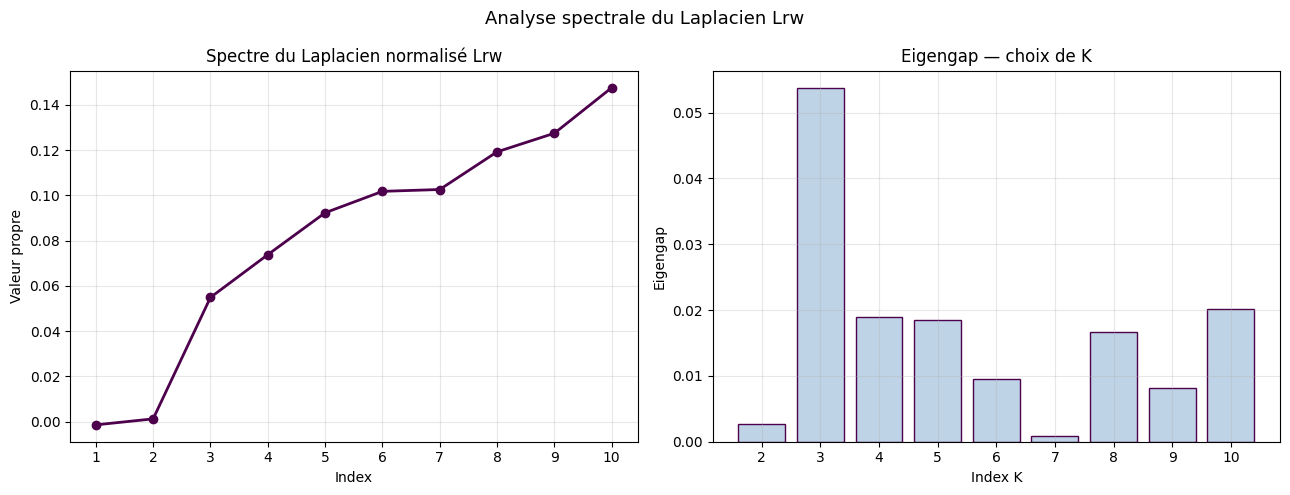

Valeurs propres :
  λ1 = -0.0014
  λ2 = 0.0012  (eigengap = 0.0027)
  λ3 = 0.0549  (eigengap = 0.0537)
  λ4 = 0.0738  (eigengap = 0.0189)
  λ5 = 0.0923  (eigengap = 0.0185)
  λ6 = 0.1018  (eigengap = 0.0095)
  λ7 = 0.1026  (eigengap = 0.0008)
  λ8 = 0.1192  (eigengap = 0.0166)
  λ9 = 0.1275  (eigengap = 0.0082)
  λ10 = 0.1476  (eigengap = 0.0201)


In [ ]:
import scipy.sparse as sp
from scipy.sparse.linalg import eigsh

# Construction du Laplacien normalisé Lrw
A_sparse = sp.csr_matrix(A)
degrees = np.array(A_sparse.sum(axis=1)).flatten()
D_inv = sp.diags(1.0 / degrees)
D = sp.diags(degrees)
L = D - A_sparse
L_rw = D_inv @ L

# 10 premières valeurs propres
eigenvalues, _ = eigsh(L_rw, k=10, which='SM')
eigenvalues = np.sort(np.real(eigenvalues))

# Eigengap
eigengaps = np.diff(eigenvalues)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(range(1, len(eigenvalues)+1), eigenvalues,
         'o-', color='#4D004B', linewidth=2)
ax1.set_xlabel('Index')
ax1.set_ylabel('Valeur propre')
ax1.set_title('Spectre du Laplacien normalisé Lrw')
ax1.set_xticks(range(1, len(eigenvalues)+1))
ax1.grid(True, alpha=0.3)

ax2.bar(range(2, len(eigenvalues)+1), eigengaps,
        color='#BFD3E6', edgecolor='#4D004B')
ax2.set_xlabel('Index K')
ax2.set_ylabel('Eigengap')
ax2.set_title('Eigengap — choix de K')
ax2.set_xticks(range(2, len(eigenvalues)+1))
ax2.grid(True, alpha=0.3)

plt.suptitle("Analyse spectrale du Laplacien Lrw", fontsize=13)
plt.tight_layout()
plt.show()

print("Valeurs propres :")
for i, v in enumerate(eigenvalues):
    gap = f"  (eigengap = {eigengaps[i-1]:.4f})" if i > 0 else ""
    print(f"  λ{i+1} = {v:.4f}{gap}")

Le spectre du Laplacien normalisé $L_{rw}$ montre que :

- $\lambda_1 \approx 0$ : confirme que le graphe est bien connexe (une seule composante)
- $\lambda_2 \approx 0$ : très proche de zéro, ce qui suggère que le graphe 
est "presque" composé de deux parties bien séparées
- À partir de $\lambda_3$ les valeurs propres augmentent plus franchement

L'eigengap est **maximal entre $\lambda_2$ et $\lambda_3$** (gap $\approx$ 0.053), 
ce qui selon l'heuristique recommande **K=2** le saut le plus important 
se produit après la 2ème valeur propre.

Ces deux critères convergent donc vers **K=2**, ce qui confirme le choix 
fait précédemment avec le K-means et le score de silhouette.

#### 4.2.2 Application du Spectral Clustering

L'eigengap confirme **K=2**. Nous appliquons le Spectral Clustering 
avec le Laplacien normalisé $L_{rw}$ sur notre graphe k-NN (k=7).

In [ ]:
from sklearn.cluster import SpectralClustering

spectral = SpectralClustering(n_clusters=2, 
                               affinity='precomputed',
                               assign_labels='kmeans',
                               random_state=42)

A_dense = A.toarray().astype(float)
spectral_labels = spectral.fit_predict(A_dense)

sil_spectral = silhouette_score(X_scaled, spectral_labels)

print(f"Taille des clusters :")
unique, counts = np.unique(spectral_labels, return_counts=True)
for k, n in zip(unique, counts):
    print(f"  Cluster {k+1} : {n} individus")
print(f"\nScore de silhouette : {sil_spectral:.3f}")

Taille des clusters :
  Cluster 1 : 339 individus
  Cluster 2 : 113 individus

Score de silhouette : 0.292


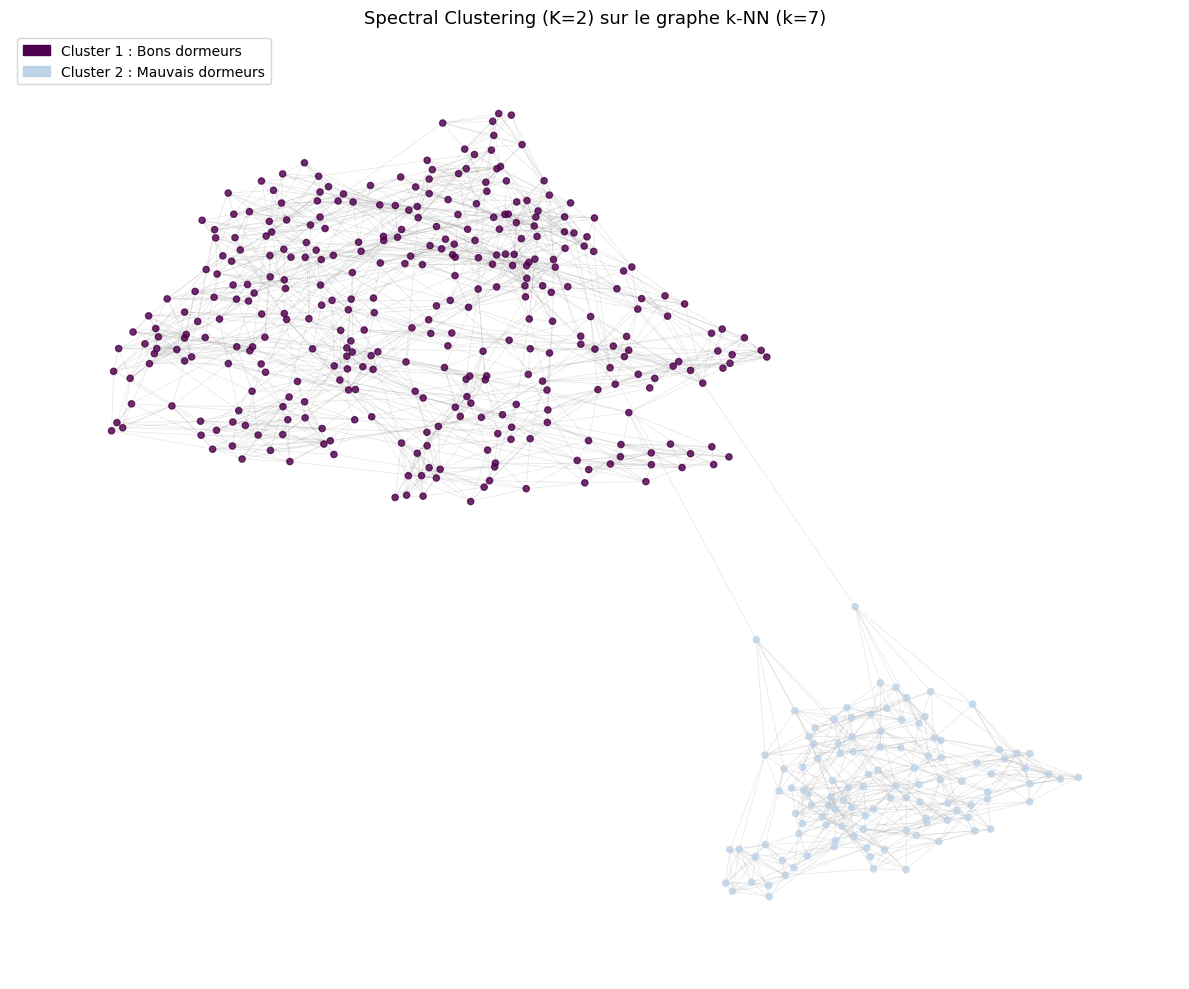

In [ ]:
plt.figure(figsize=(12, 10))

colors_spectral = ['#4D004B' if l == 0 else '#BFD3E6' 
                   for l in spectral_labels]

nx.draw_networkx_nodes(G, pos, node_size=20,
                       node_color=colors_spectral, alpha=0.8)
nx.draw_networkx_edges(G, pos, alpha=0.2, 
                       width=0.5, edge_color='gray')

# Légende manuelle
from matplotlib.patches import Patch
legend = [Patch(color='#4D004B', label='Cluster 1 : Bons dormeurs'),
          Patch(color='#BFD3E6', label='Cluster 2 : Mauvais dormeurs')]
plt.legend(handles=legend, loc='upper left', fontsize=10)

plt.title(f'Spectral Clustering (K=2) sur le graphe k-NN (k={K_GRAPH})', 
          fontsize=13)
plt.axis('off')
plt.tight_layout()
plt.show()

Le Spectral Clustering identifie parfaitement les deux communautés 
du graphe la séparation est nette et cohérente avec la structure 
visuelle observée précédemment.

Le **Cluster 1** (violet, 339 individus) correspond aux bons dormeurs, 
fortement connectés entre eux, formant le grand groupe dense en haut. 
Le **Cluster 2** (bleu, 113 individus) regroupe les mauvais dormeurs, 
également bien connectés entre eux, formant le petit groupe isolé en bas.

Le fait que les deux communautés soient **quasi-séparées dans le graphe** 
— reliées par seulement quelques arêtes — est parfaitement cohérent avec 
le faible $\lambda_2 \approx 0$ observé dans le spectre du Laplacien.